<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">
<br>
<h1 style="font-family:verdana; font-size:26px"><center>~ Seleksi Lab AI 2026: Dere Detector dengan Multimodal Ensemble ~</center></h1>
<h3 style="font-family:verdana; font-size:14px; color:gray"><center>Klasifikasi dere archetype dari deskripsi kepribadian dan citra karakter</center></h3>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# **DereDetector**

**Riantama Putra — 18224061**


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Daftar Isi

1. [**Pendahuluan**](#1)
2. [**Inisialisasi**](#2)
3. [**Analisis Data Eksploratif**](#3)
4. [**Prapemrosesan dan Feature Engineering**](#4)
5. [**Leakage-Aware Split dan Validasi**](#5)
6. [**Pemodelan**](#6)
7. [**Inferensi dan Submisi**](#7)
8. [**Pasca-Analisis**](#8)
9. [**Daftar Pustaka**](#9)


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Pendahuluan <a name="1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


## Kompetisi

**Dere Detector** merupakan kompetisi pada Task #3 Seleksi Laboratorium Intelegensi Buatan 2026. Tugasnya adalah memprediksi *dere archetype* karakter anime, manga, dan *light novel* berdasarkan tiga sumber informasi yang tersedia di dataset kompetisi: `character_name`, deskripsi `personality`, dan gambar karakter.

- **Tugas**: klasifikasi multimodal tiga kelas
- **Kelas target**: `deredere`, `kuudere`, `tsundere`
- **Metrik**: *macro F1-score*
- **Platform**: Kaggle Notebook, GPU **T4 x2**
- **Batasan**: tidak menggunakan data eksternal; *pretrained model* diperbolehkan; model generatif LLM/VLM tidak digunakan untuk prediksi

Pemilihan *macro F1-score* membuat setiap kelas mempunyai kontribusi yang sama terhadap skor akhir, sehingga model tidak cukup hanya bekerja baik pada kelas dengan jumlah sampel terbesar.


---

## Dataset

Dataset terdiri atas **707 karakter train** dan **302 karakter test**. Setiap baris memiliki `character_id`, `character_name`, `file_name`, serta `personality`; `train.csv` menambahkan kolom `label`.

Satu detail penting dari konstruksi data adalah bahwa karakter yang muncul pada lebih dari satu daftar hanya dimasukkan sekali berdasarkan urutan pemrosesan **Deredere → Kuudere → Tsundere**. Konvensi ini berpotensi menimbulkan contoh yang secara semantik ambigu, sehingga analisis kesalahan tidak boleh langsung menganggap seluruh ketidaksepakatan model sebagai kesalahan anotasi.


---

## Pendekatan: Multimodal Ensemble dengan V3 EVA×2

Eksperimen berkembang dari baseline tekstual dan visual menuju ensemble multimodal. Arsitektur final mempertahankan **DeBERTa-v3-large NLI** sebagai expert semantik utama, **ModernBERT-large** sebagai text expert independen, **TF-IDF** sebagai sinyal leksikal, **WD EVA02-Large** sebagai expert visual anime, dan **SigLIP2** sebagai representasi visual tambahan.

```
Personality + Character Name
        |
        +--> DeBERTa-v3-large NLI -----------+
        |                                     |
        +--> ModernBERT-large ----------------+----> constrained late fusion
        |                                     |             |
        +--> Word + Char TF-IDF --------------+             +--> EVA weight x2
                                                              |
Character Image                                               +--> final prediction
        |                                                     |
        +--> WD EVA02-Large ----------------------------------+
        |       +--> emotion/expression cues --> NLI premise
        |
        +--> SigLIP2 -----------------------------------------+
```

Bobot EVA02 pada *blend* V3 utama kemudian digandakan dan seluruh bobot dinormalisasi ulang. Ablasi satu dimensi ini menghasilkan **public Macro F1 0,83504**, skor terbaik selama rangkaian eksperimen.


---

## Hipotesis Awal

1. Deskripsi `personality` membawa sinyal paling langsung terhadap *dere archetype*, sehingga text encoder semantik seharusnya menjadi expert utama.
2. Formulasi NLI lebih cocok untuk dataset kecil daripada mengganti seluruh pengetahuan *pretrained* dengan head klasifikasi acak, karena nama kelas dapat direpresentasikan sebagai hipotesis semantik.
3. Gambar kemungkinan lemah jika berdiri sendiri, tetapi ekspresi dan gaya visual dapat menjadi sinyal pelengkap ketika text expert ragu.
4. Pada 707 sampel, pencarian *decision policy* yang terlalu fleksibel berisiko *meta-overfitting*. Karena itu, fusion akhir dibatasi dan perubahan terhadap champion harus sederhana serta dapat dijelaskan.


---

## Referensi Utama

- Task #3 Seleksi Laboratorium Intelegensi Buatan 2026 dan kompetisi Dere Detector.
- Model card `MoritzLaurer/deberta-v3-large-zeroshot-v2.0` untuk formulasi NLI `entailment` vs `not_entailment`.
- Model card `answerdotai/ModernBERT-large` sebagai text encoder independen.
- Model card `SmilingWolf/wd-eva02-large-tagger-v3` dan `SmilingWolf/wd-convnext-tagger-v3` untuk fitur visual anime.
- Tschannen dkk. (2025), SigLIP 2, sebagai representasi visual semantik non-generatif.


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Inisialisasi <a name="2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


## Environment


In [1]:
!nvidia-smi


Sat Aug 22 06:14:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

> Catatan untuk asisten: notebook ini dirancang untuk **Run All** pada Kaggle dengan **T4 x2** dan Internet aktif. Seluruh *seed*, fold, feature selection, kalibrasi, dan fusion dibentuk dari data kompetisi. `FAST_DEV_RUN=1` hanya digunakan untuk pemeriksaan integrasi dan bukan untuk menghasilkan submisi final.


In [2]:
import os, platform, sys
print('Python :', sys.version)
print('OS     :', platform.system(), platform.release())
print('CWD    :', os.getcwd())


Python : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
OS     : Linux 6.12.90+
CWD    : /kaggle/working


---

## Instalasi

Pustaka dipasang dengan rentang versi yang sama dengan run V3.2. `transformers` digunakan untuk DeBERTa, ModernBERT, dan SigLIP2; `timm` serta Hugging Face Hub digunakan untuk WD anime tagger.


In [3]:
import os, sys, subprocess

FAST_DEV_RUN = os.environ.get("FAST_DEV_RUN", "0") == "1"

if not FAST_DEV_RUN:
    packages = [
        "transformers>=4.56,<5",
        "timm>=1.0.19,<2",
        "accelerate>=1.10,<2",
        "sentencepiece>=0.2.0",
        "huggingface_hub>=0.34,<1",
        "einops>=0.8",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages])

print("FAST_DEV_RUN =", FAST_DEV_RUN)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.5 MB/s eta 0:00:00
FAST_DEV_RUN = False


---

## Pustaka

Seluruh impor dan konfigurasi inti diletakkan di satu tempat. Reproduksibilitas dijaga dengan *seed* tetap, deterministic cuDNN, fixed fold, serta konfigurasi model yang tidak berubah sepanjang notebook.


In [4]:
import gc, json, math, random, re, hashlib, unicodedata, warnings, shutil, zipfile, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.pipeline import FeatureUnion
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, log_loss
from sklearn.ensemble import ExtraTreesClassifier
import joblib

warnings.filterwarnings("ignore")

SEED = 42
N_FOLDS = 3 if FAST_DEV_RUN else 5
LABELS = ["deredere", "kuudere", "tsundere"]
LABEL2ID = {x:i for i,x in enumerate(LABELS)}
ID2LABEL = {i:x for x,i in LABEL2ID.items()}

CONVNEXT_MODEL_NAME = "SmilingWolf/wd-convnext-tagger-v3"
EVA_MODEL_NAME = "SmilingWolf/wd-eva02-large-tagger-v3"
SIGLIP2_MODEL_NAME = "google/siglip2-base-patch16-384"
NLI_LARGE_MODEL_NAME = "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"
MODERNBERT_MODEL_NAME = "answerdotai/ModernBERT-large"

RUN_CONVNEXT = not FAST_DEV_RUN
RUN_EVA = not FAST_DEV_RUN
RUN_SIGLIP2 = not FAST_DEV_RUN
RUN_NLI_LARGE = not FAST_DEV_RUN
RUN_MODERNBERT = not FAST_DEV_RUN
TRAIN_FINAL_DEPLOY_MODELS = (not FAST_DEV_RUN) and os.environ.get("TRAIN_FINAL_DEPLOY_MODELS", "1") == "1"

# The first Kaggle V3 run showed the full NLI variant was stronger than the frozen variant.
# Keep the stronger expert by default: this both improves the NLI anchor and saves ~2 hours on T4x2.
NLI_VARIANTS = [
    {"name":"nli_large_full", "seed":42, "freeze_bottom":0, "lr":6e-6},
]
NLI_EPOCHS = 2
MODERN_EPOCHS = 3
NLI_MAXLEN = 384
MODERN_MAXLEN = 384

WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("/mnt/data/dere_v3_working")
ARTIFACT_DIR = WORK_DIR / "artifacts_v3"
MODEL_DIR = WORK_DIR / "models_v3"
CACHE_DIR = WORK_DIR / "cache_v3"
for p in [WORK_DIR, ARTIFACT_DIR, MODEL_DIR, CACHE_DIR]: p.mkdir(parents=True, exist_ok=True)

START_TIME = time.time()
def elapsed_h(): return (time.time()-START_TIME)/3600

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
    except Exception: pass
seed_everything()

def disk_free_gb(path=WORK_DIR): return shutil.disk_usage(path).free/1024**3

def clean_cuda():
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    except Exception: pass

print("Work dir:",WORK_DIR)
print(f"Free disk: {disk_free_gb():.2f} GB")
try:
    import torch
    print("torch:",torch.__version__,"CUDA:",torch.cuda.is_available(),"GPU count:",torch.cuda.device_count())
    for i in range(torch.cuda.device_count()): print(f"GPU {i}:",torch.cuda.get_device_name(i))
    if not FAST_DEV_RUN and torch.cuda.is_available():
        x=torch.randn(256,256,device="cuda"); _=x@x; del x,_; torch.cuda.empty_cache(); print("CUDA kernel smoke test: PASS")
except Exception as exc: print("Torch runtime info unavailable:",exc)


Work dir: /kaggle/working
Free disk: 19.50 GB
torch: 2.10.0+cu128 CUDA: True GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
CUDA kernel smoke test: PASS


---

## Seed

*Seed* utama ditetapkan ke `42`. Operasi GPU tetap dapat memiliki variasi numerik sangat kecil antar-runtime, tetapi sumber keacakan Python, NumPy, PyTorch, fold, model linear, dan Trainer dikunci secara eksplisit.


In [5]:
print('SEED                  =', SEED)
print('N_FOLDS               =', N_FOLDS)
print('TRAIN_FINAL_MODELS    =', TRAIN_FINAL_DEPLOY_MODELS)
print('NLI model             =', NLI_LARGE_MODEL_NAME)
print('ModernBERT model      =', MODERNBERT_MODEL_NAME)
print('EVA model             =', EVA_MODEL_NAME)
print('SigLIP2 model         =', SIGLIP2_MODEL_NAME)


SEED                  = 42
N_FOLDS               = 5
TRAIN_FINAL_MODELS    = True
NLI model             = MoritzLaurer/deberta-v3-large-zeroshot-v2.0
ModernBERT model      = answerdotai/ModernBERT-large
EVA model             = SmilingWolf/wd-eva02-large-tagger-v3
SigLIP2 model         = google/siglip2-base-patch16-384


---

## Settings

Konfigurasi eksperimen final sengaja sempit: lima fold, satu varian DeBERTa NLI yang terbukti paling kuat pada V3.2, dua epoch NLI, tiga epoch ModernBERT, dan panjang konteks maksimum 384 token. Model *full-data* untuk deployment disimpan secara default setelah model selection selesai.


---

## Autentikasi Hugging Face

Model yang digunakan bersifat publik dan tidak membutuhkan token khusus pada konfigurasi normal. Internet Kaggle harus aktif agar model dan metadata tag dapat diunduh pertama kali. Apabila model sudah berada di cache Kaggle, Hugging Face Hub akan menggunakan cache tersebut secara otomatis.


---

## Unduh Data

Notebook **tidak mengunduh data eksternal**. Dataset Dere Detector harus ditambahkan sebagai Kaggle Dataset/Input. Fungsi discovery juga mendukung `dere-detector.zip` untuk reproduksi lokal.


---

## Ekstraksi ZIP dan Kontrak Dataset

Selain menemukan lokasi dataset, sel berikut memverifikasi skema kolom, keunikan `character_id`, tiga kelas resmi, dan kebocoran target dari struktur `file_name`. Prefix folder label **hanya digunakan untuk I/O gambar dan dilarang menjadi fitur prediktif**.


In [6]:
REQUIRED_TRAIN_COLUMNS = {"character_id", "character_name", "file_name", "personality", "label"}
REQUIRED_TEST_COLUMNS = {"character_id", "character_name", "file_name", "personality"}

def is_dataset_root(path: Path) -> bool:
    try:
        if not all((path/f).exists() for f in ["train.csv","test.csv","sample_submission.csv"]): return False
        tr_preview=pd.read_csv(path/"train.csv",nrows=2); te_preview=pd.read_csv(path/"test.csv",nrows=2)
        trc=set(tr_preview.columns); tec=set(te_preview.columns)
        if not (REQUIRED_TRAIN_COLUMNS.issubset(trc) and REQUIRED_TEST_COLUMNS.issubset(tec)): return False
        if len(tr_preview) and not (path/"train"/str(tr_preview.file_name.iloc[0])).exists(): return False
        if len(te_preview) and not (path/"test"/str(te_preview.file_name.iloc[0])).exists(): return False
        return True
    except Exception: return False

def find_dataset_root():
    direct=[Path("/mnt/data/dere_data"),Path("/mnt/data/dere_detector"),Path("/kaggle/working/dere_detector"),Path.cwd()]
    for p in direct:
        if p.exists() and is_dataset_root(p): return p
    for base in [Path("/kaggle/input"),Path("/mnt/data")]:
        if base.exists():
            for tr in base.rglob("train.csv"):
                if is_dataset_root(tr.parent): return tr.parent
    for base in [Path("/kaggle/input"),Path("/mnt/data")]:
        if not base.exists(): continue
        for z in base.rglob("dere-detector.zip"):
            out=CACHE_DIR/"dataset"; out.mkdir(exist_ok=True)
            with zipfile.ZipFile(z) as f: f.extractall(out)
            if is_dataset_root(out): return out
            for tr in out.rglob("train.csv"):
                if is_dataset_root(tr.parent): return tr.parent
    raise FileNotFoundError("Dere Detector dataset not found.")

DATA_ROOT=find_dataset_root()
train=pd.read_csv(DATA_ROOT/"train.csv")
test=pd.read_csv(DATA_ROOT/"test.csv")
sample_submission=pd.read_csv(DATA_ROOT/"sample_submission.csv")

assert REQUIRED_TRAIN_COLUMNS.issubset(train.columns)
assert REQUIRED_TEST_COLUMNS.issubset(test.columns)
assert train.character_id.is_unique and test.character_id.is_unique
assert set(train.label.unique())==set(LABELS)

train["image_path"]=train.file_name.map(lambda p: DATA_ROOT/"train"/p)
test["image_path"]=test.file_name.map(lambda p: DATA_ROOT/"test"/p)

prefix=train.file_name.astype(str).str.split("/").str[0]
prefix_match=(prefix==train.label).mean()
assert prefix_match==1.0

print("DATA_ROOT =",DATA_ROOT)
print("Train/Test:",train.shape,test.shape)
print("Actual labels:",sorted(train.label.unique()))
print("Sample submission labels:",sample_submission.label.value_counts().to_dict())
print(f"file_name folder-prefix == label: {prefix_match:.3f} -> EXCLUDED from ML features")
display(train.head(3))


DATA_ROOT = /kaggle/input/competitions/dere-detector
Train/Test: (707, 6) (302, 5)
Actual labels: ['deredere', 'kuudere', 'tsundere']
Sample submission labels: {'dandere': 302}
file_name folder-prefix == label: 1.000 -> EXCLUDED from ML features


,character_id,character_name,file_name,personality,label,image_path
0,8d0fb0d4b2424490,Ritsu Tainaka,deredere/8d0fb0d4b2424490.webp,Ritsu is the source of fun and encouragement i...,deredere,/kaggle/input/competitions/dere-detector/train...
1,5d9d37d82f187c39,"Suelecia ""Sue"" Zagan Analeit",kuudere/5d9d37d82f187c39.webp,"Sue is extremely attached to Schlain, to the p...",kuudere,/kaggle/input/competitions/dere-detector/train...
2,ae50b1dc411ef8a1,Fate Testarossa,kuudere/ae50b1dc411ef8a1.webp,Fate is a very serious and strong-willed perso...,kuudere,/kaggle/input/competitions/dere-detector/train...


> ### Insights
> `file_name` pada data train memiliki prefix folder yang identik dengan label. Menggunakannya sebagai fitur akan menghasilkan kebocoran target yang hampir sempurna. Karena itu, kolom ini hanya dipakai untuk menemukan berkas gambar; seluruh model belajar dari `personality`, `character_name`, atau piksel gambar.


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Data Eksploratif <a name="3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


EDA dilakukan pada data kompetisi mentah untuk memahami distribusi label, panjang teks, kualitas gambar, duplikasi, dan potensi pergeseran train-test sebelum feature engineering dilakukan.


---

## Distribusi Kelas dan Panjang Personality

Distribusi kelas menentukan seberapa aman penggunaan akurasi biasa dan memperkuat alasan penggunaan *macro F1*. Panjang `personality` membantu menentukan batas konteks text encoder.


,count,fraction
label,,
deredere,210,0.297030
kuudere,221,0.312588
tsundere,276,0.390382


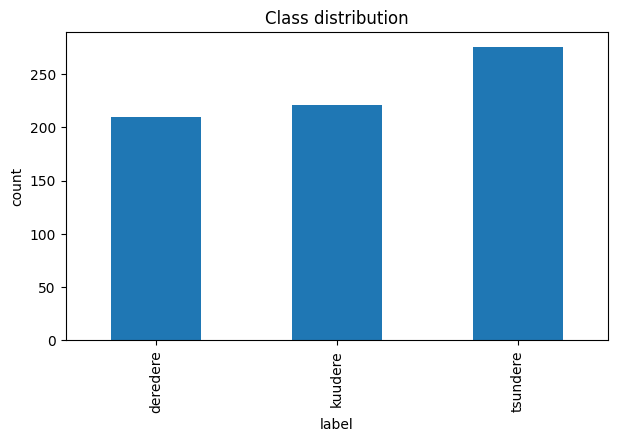

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
deredere,210.0,173.6,48.4,63.0,136.5,191.0,214.0,231.0
kuudere,221.0,172.9,48.4,67.0,136.0,190.0,213.0,237.0
tsundere,276.0,175.9,49.6,66.0,137.2,198.0,215.2,239.0


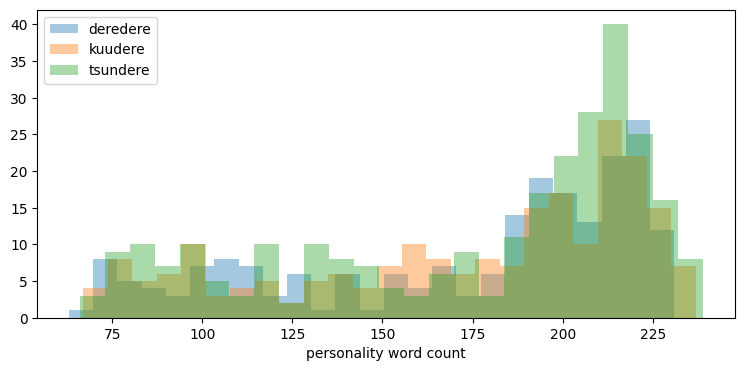

Missing train:


,missing
character_name,0
character_id,0
personality,0
label,0
file_name,0


Missing test:


,missing
personality,0
character_name,0
file_name,0
character_id,0


In [7]:
class_counts=train.label.value_counts().reindex(LABELS)
display(pd.DataFrame({"count":class_counts,"fraction":class_counts/len(train)}))
class_counts.plot(kind="bar",figsize=(7,4),title="Class distribution")
plt.ylabel("count"); plt.show()

for df in [train,test]:
    df["word_count"]=df.personality.fillna("").str.split().str.len()
    df["char_count"]=df.personality.fillna("").str.len()

display(train.groupby("label")["word_count"].describe().round(1))
plt.figure(figsize=(9,4))
for label in LABELS:
    plt.hist(train.loc[train.label==label,"word_count"],bins=25,alpha=.4,label=label)
plt.legend(); plt.xlabel("personality word count"); plt.show()

print("Missing train:")
display(train[list(REQUIRED_TRAIN_COLUMNS)].isna().sum().to_frame("missing"))
print("Missing test:")
display(test[list(REQUIRED_TEST_COLUMNS)].isna().sum().to_frame("missing"))


> ### Insights
> Dataset tidak seimbang secara ekstrem, tetapi `tsundere` merupakan kelas terbesar. Karena metrik kompetisi adalah *macro F1*, setiap fold dibuat *stratified* dan model linear menggunakan `class_weight='balanced'` agar kelas minoritas tidak diabaikan.


---

## Sampel Gambar per Kelas

Contoh gambar digunakan untuk memeriksa apakah ketiga kelas memiliki pola visual yang jelas atau justru sangat tumpang tindih. Visual ini juga membantu menjelaskan mengapa image-only branch tidak diharapkan menjadi classifier utama.


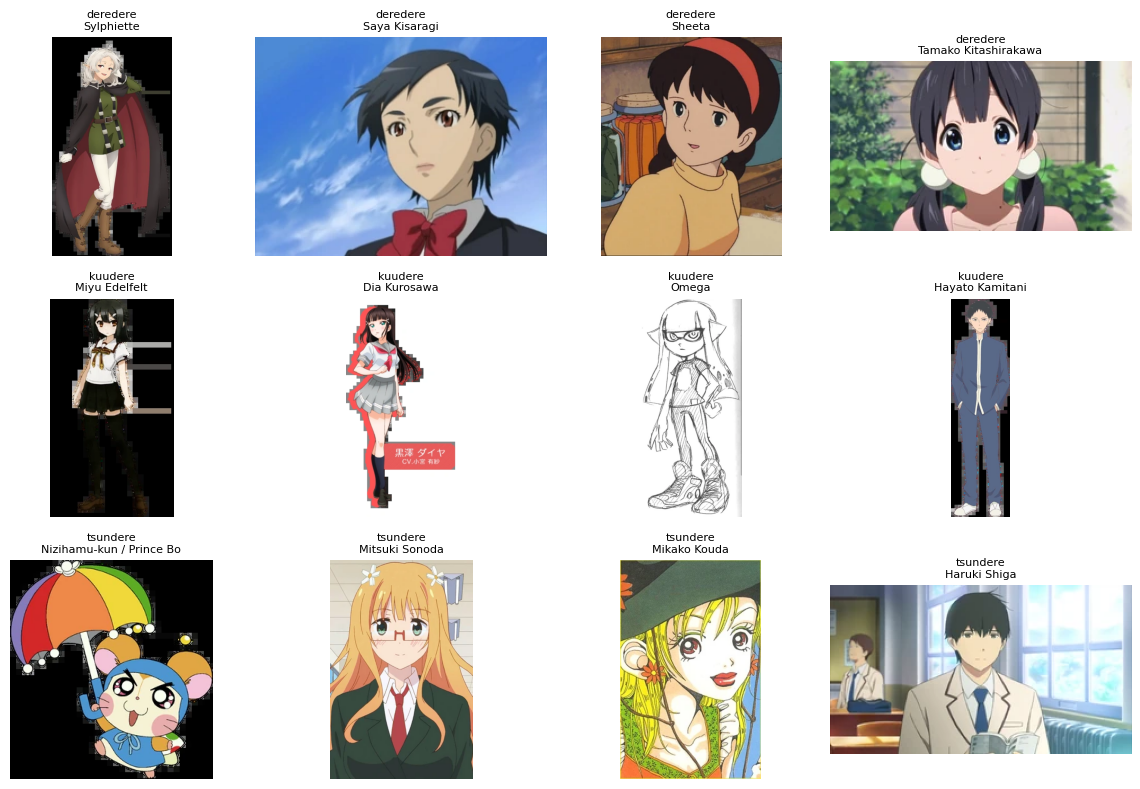

In [8]:
fig, axes = plt.subplots(len(LABELS), 4, figsize=(12, 8))
for r, label in enumerate(LABELS):
    rows = train.loc[train.label == label].sample(n=min(4, (train.label == label).sum()), random_state=SEED)
    for c, (_, row) in enumerate(rows.iterrows()):
        with Image.open(row.image_path) as im:
            axes[r, c].imshow(im.convert('RGB'))
        axes[r, c].set_title(f'{label}\n{row.character_name}', fontsize=8)
        axes[r, c].axis('off')
plt.tight_layout()
plt.show()


> ### Insights
> Tidak ada karakteristik visual tunggal yang mendefinisikan `deredere`, `kuudere`, atau `tsundere`. Ekspresi dapat membantu, tetapi archetype pada dasarnya merupakan konsep kepribadian. Hal ini mendukung desain text-dominant dengan visual sebagai evidence pelengkap.


---

## Audit Resolusi dan Integritas Gambar

Sel berikut memverifikasi keberadaan, format, resolusi, SHA256, serta kemungkinan gambar korup. Hash juga dipakai untuk mencari *exact duplicate* tanpa menggunakan informasi label dari test.


In [9]:
def normalize_name(x):
    x=unicodedata.normalize("NFKC",str(x)).lower().strip()
    return re.sub(r"\s+"," ",x)

def sha256_bytes(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(1024*1024),b""): h.update(chunk)
    return h.hexdigest()

def audit_images(df,split):
    rows=[]
    for idx,row in df.iterrows():
        p=Path(row.image_path)
        rec={"split":split,"row_index":idx,"character_id":row.character_id,"exists":p.exists(),"corrupt":False,"width":np.nan,"height":np.nan,"aspect_ratio":np.nan,"format":None,"sha256":None}
        if p.exists():
            try:
                rec["sha256"]=sha256_bytes(p)
                with Image.open(p) as im:
                    rec["width"],rec["height"]=im.size; rec["aspect_ratio"]=im.width/max(im.height,1); rec["format"]=im.format; im.verify()
            except Exception: rec["corrupt"]=True
        rows.append(rec)
    return pd.DataFrame(rows)

audit_cache=ARTIFACT_DIR/"image_audit.csv"
if audit_cache.exists(): image_audit=pd.read_csv(audit_cache)
else:
    image_audit=pd.concat([audit_images(train,"train"),audit_images(test,"test")],ignore_index=True)
    image_audit.to_csv(audit_cache,index=False)

tr_a=image_audit[image_audit.split=="train"].set_index("character_id")
te_a=image_audit[image_audit.split=="test"].set_index("character_id")
train["image_sha256"]=train.character_id.map(tr_a.sha256); test["image_sha256"]=test.character_id.map(te_a.sha256)
train["name_norm"]=train.character_name.map(normalize_name); test["name_norm"]=test.character_name.map(normalize_name)
train["personality_sha256"]=train.personality.fillna("").map(lambda s:hashlib.sha256(s.encode()).hexdigest())
test["personality_sha256"]=test.personality.fillna("").map(lambda s:hashlib.sha256(s.encode()).hexdigest())

print("Missing/corrupt images:")
display(image_audit.groupby("split")[["exists","corrupt"]].agg(["count","sum"]))
print("Image dimensions:")
display(image_audit.groupby("split")[["width","height","aspect_ratio"]].describe().round(2))

print("Duplicate train names:")
display(train[train.name_norm.duplicated(False)][["character_id","character_name","label"]].sort_values("character_name"))
print("Duplicate train image hashes:")
display(train[train.image_sha256.duplicated(False)][["character_id","character_name","label","file_name","image_sha256"]])

train["content_key"]=train.personality_sha256+"::"+train.image_sha256
test["content_key"]=test.personality_sha256+"::"+test.image_sha256
key_labels=train.groupby("content_key").label.agg(list)
safe_exact={k:v[0] for k,v in key_labels.items() if len(set(v))==1}
test["exact_train_match_label"]=test.content_key.map(safe_exact)
print("Exact train-test content matches:")
display(test[test.exact_train_match_label.notna()][["character_id","character_name","exact_train_match_label"]])


Missing/corrupt images:


exists      corrupt    
       count  sum   count sum
split                        
test     302  302     302   0
train    707  707     707   0

Image dimensions:


width                                                    height  \
       count    mean     std   min    25%    50%    75%     max  count   
split                                                                    
test   302.0  297.99  163.48  70.0  267.0  268.0  268.0  1481.0  302.0   
train  707.0  283.09  121.90  80.0  256.0  268.0  268.0  1000.0  707.0   

               ...                 aspect_ratio                                \
         mean  ...     75%     max        count  mean   std   min   25%   50%   
split          ...                                                              
test   390.33  ...  480.75  2570.0        302.0  0.95  0.47  0.27  0.62  0.82   
train  369.61  ...  443.00  2000.0        707.0  0.93  0.43  0.25  0.61  0.80   

                   
        75%   max  
split              
test   1.17  1.97  
train  1.05  2.00  

[2 rows x 24 columns]

Duplicate train names:


,character_id,character_name,label
293,b470410c41d74dd9,Ayaka Sajyou,tsundere
392,338369ac9ad2c437,Ayaka Sajyou,kuudere


Duplicate train image hashes:


,character_id,character_name,label,file_name,image_sha256
109,d4a12d4418d8ae49,Chizuru Ichinose / Mizuhara,tsundere,tsundere/d4a12d4418d8ae49.webp,2a684367da048f00993b1b27ff14b74369750453047db9...
313,4e7ed7ea0e33a511,Mini Yaemori,deredere,deredere/4e7ed7ea0e33a511.webp,2a684367da048f00993b1b27ff14b74369750453047db9...


Exact train-test content matches:


,character_id,character_name,exact_train_match_label
46,2df22fc7f52a636f,Jinguuji Tsukasa,kuudere


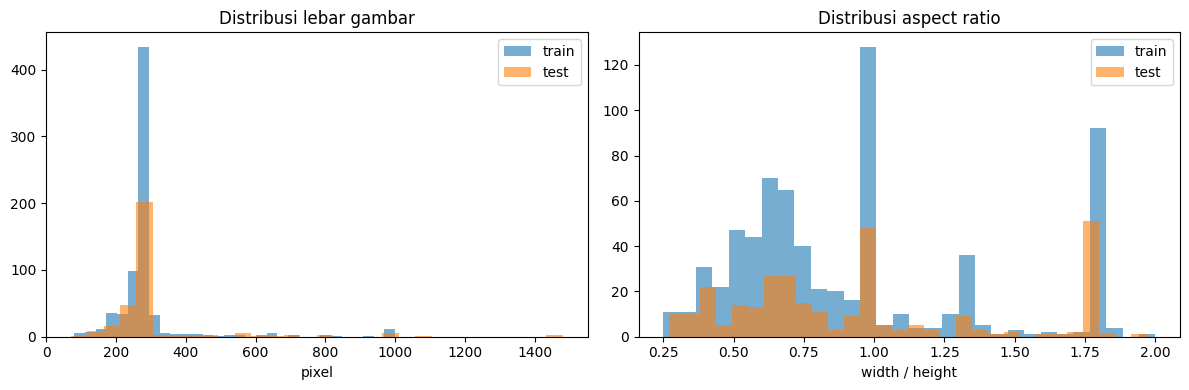

In [10]:
valid_img = image_audit[(image_audit['exists']) & (~image_audit['corrupt'])].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(valid_img.loc[valid_img.split=='train', 'width'].dropna(), bins=30, alpha=.6, label='train')
axes[0].hist(valid_img.loc[valid_img.split=='test', 'width'].dropna(), bins=30, alpha=.6, label='test')
axes[0].set_title('Distribusi lebar gambar'); axes[0].set_xlabel('pixel'); axes[0].legend()
axes[1].hist(valid_img.loc[valid_img.split=='train', 'aspect_ratio'].dropna(), bins=30, alpha=.6, label='train')
axes[1].hist(valid_img.loc[valid_img.split=='test', 'aspect_ratio'].dropna(), bins=30, alpha=.6, label='test')
axes[1].set_title('Distribusi aspect ratio'); axes[1].set_xlabel('width / height'); axes[1].legend()
plt.tight_layout(); plt.show()


> ### Insights
> Audit menemukan dua fenomena penting: ada *exact train-test content match* yang dapat ditangani secara deterministik, dan ada gambar train identik yang dapat memiliki label berbeda. Temuan kedua menunjukkan bahwa piksel saja tidak cukup untuk menentukan archetype; deskripsi kepribadian tetap menjadi modalitas utama.


---

## Pengecekan Train-Test Shift

*Adversarial validation* menguji apakah teks `personality` train dan test mudah dibedakan. Model ini hanya diagnostik dan tidak pernah digunakan untuk membuat prediksi dere.


In [11]:
# Adversarial validation: only diagnostic, never used as predictive feature.
adv=pd.concat([train[["personality"]].assign(is_test=0),test[["personality"]].assign(is_test=1)],ignore_index=True)
vec=TfidfVectorizer(strip_accents="unicode",ngram_range=(1,2),min_df=2,max_features=25000,sublinear_tf=True)
X=vec.fit_transform(adv.personality.fillna(""))
cv=StratifiedKFold(n_splits=3 if FAST_DEV_RUN else 5,shuffle=True,random_state=SEED)
p=cross_val_predict(LogisticRegression(C=1,max_iter=3000,class_weight="balanced"),X,adv.is_test,cv=cv,method="predict_proba",n_jobs=1)[:,1]
print(f"Adversarial validation ROC-AUC: {roc_auc_score(adv.is_test,p):.4f}")


Adversarial validation ROC-AUC: 0.5108


> ### Insights
> ROC-AUC yang mendekati 0,5 berarti distribusi teks train dan test tidak menunjukkan pemisahan kasar. Perbedaan local CV dan public leaderboard lebih mungkin berasal dari ukuran dataset kecil, ambiguity, dan variance daripada domain shift tekstual yang besar.


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Prapemrosesan dan Feature Engineering <a name="4"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


Prapemrosesan dibuat sesederhana mungkin agar tidak menghilangkan sinyal semantik. Teks tidak dibersihkan secara agresif; tokenizer model menangani subword dan tanda baca. Pada gambar, seluruh proses menjaga *aspect ratio* dengan padding putih sebelum transformasi model pretrained.


---

## Prapemrosesan Gambar

RGBA/transparency dikompositkan ke latar putih dan gambar dipad menjadi persegi. WD tagger menggunakan transformasi resmi dari konfigurasi TIMM masing-masing model.


In [12]:
def pil_ensure_rgb(image):
    if image.mode not in ["RGB","RGBA"]: image=image.convert("RGBA") if "transparency" in image.info else image.convert("RGB")
    if image.mode=="RGBA":
        canvas=Image.new("RGBA",image.size,(255,255,255,255)); canvas.alpha_composite(image); image=canvas.convert("RGB")
    return image

def pil_pad_square(image):
    w,h=image.size; s=max(w,h); canvas=Image.new("RGB",(s,s),(255,255,255)); canvas.paste(image,((s-w)//2,(s-h)//2)); return canvas


---

## Cache Fitur Kompetisi

Fitur yang berasal dari run sebelumnya boleh dipakai kembali karena dihitung dari **dataset kompetisi yang sama**. Jika cache tidak tersedia, notebook mengekstrak ulang seluruh fitur. Mekanisme ini hanya menghemat waktu dan tidak mengubah informasi yang digunakan model.


In [13]:
def _find_any(filename):
    for base in [CACHE_DIR, Path("/kaggle/input"), Path("/mnt/data")]:
        if not base.exists(): continue
        for p in base.rglob(filename): return p
    return None

for zname in ["results-v2.zip", "results.zip"]:
    z=_find_any(zname)
    if z is not None:
        out=CACHE_DIR/("import_"+zname.replace(".zip","")); out.mkdir(parents=True,exist_ok=True)
        marker=out/".done"
        if not marker.exists():
            with zipfile.ZipFile(z) as f: f.extractall(out)
            marker.write_text("ok")
        print("Imported cache:",z)

def find_input_artifact(filename):
    return _find_any(filename)

# Bring old image audit into V3 artifact dir when present only as a convenience.
old_audit=find_input_artifact("image_audit.csv")
if old_audit and not (ARTIFACT_DIR/"image_audit.csv").exists():
    try: shutil.copy2(old_audit,ARTIFACT_DIR/"image_audit.csv")
    except Exception: pass


---

## Ekstraksi WD Anime Features

WD tagger menghasilkan dua representasi: probabilitas *general tags* dan embedding sebelum classification head. Hanya *general tags* yang diambil; character/identity tags sengaja tidak digunakan.


In [14]:
def extract_wd_features(model_name, cache_name, batch_candidates=(16,8,4,2,1)):
    import torch, timm
    from torch.utils.data import Dataset,DataLoader
    from timm.data import create_transform,resolve_data_config
    from huggingface_hub import hf_hub_download

    cache_path=ARTIFACT_DIR/cache_name
    existing=find_input_artifact(cache_name)
    if existing and not cache_path.exists(): shutil.copy2(existing,cache_path)

    tag_meta=ARTIFACT_DIR/(cache_name.replace(".npz","_tags.csv"))
    if cache_path.exists():
        d=np.load(cache_path)
        if d["train_tags"].shape[0]==len(train) and d["test_tags"].shape[0]==len(test):
            tag_csv=hf_hub_download(repo_id=model_name,filename="selected_tags.csv")
            labels_df=pd.read_csv(tag_csv,usecols=["name","category"]); names=labels_df.loc[labels_df.category==0,"name"].tolist()
            return d["train_tags"].astype(np.float32),d["test_tags"].astype(np.float32),d["train_emb"].astype(np.float32),d["test_emb"].astype(np.float32),names

    device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Extracting",model_name,"on",device)
    model=timm.create_model(f"hf_hub:{model_name}",pretrained=True).to(device).eval()
    transform=create_transform(**resolve_data_config(model.pretrained_cfg,model=model))
    tag_csv=hf_hub_download(repo_id=model_name,filename="selected_tags.csv")
    labels_df=pd.read_csv(tag_csv,usecols=["name","category"]); gen_idx=np.where(labels_df.category.to_numpy()==0)[0]; names=labels_df.loc[gen_idx,"name"].tolist()

    class DS(Dataset):
        def __init__(self,paths): self.paths=list(paths)
        def __len__(self): return len(self.paths)
        def __getitem__(self,i):
            with Image.open(self.paths[i]) as im: x=transform(pil_pad_square(pil_ensure_rgb(im)))
            return x[[2,1,0],:,:]  # WD v3 TIMM convention: RGB -> BGR

    paths=list(train.image_path)+list(test.image_path); ds=DS(paths)
    last=None
    for bs in batch_candidates:
        try:
            loader=DataLoader(ds,batch_size=bs,shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available())
            tags=[]; embs=[]
            with torch.inference_mode():
                for batch in loader:
                    batch=batch.to(device,non_blocking=True)
                    with torch.autocast(device_type="cuda",dtype=torch.float16,enabled=(device.type=="cuda")):
                        feat=model.forward_features(batch); emb=model.forward_head(feat,pre_logits=True); logits=model.forward_head(feat,pre_logits=False)
                    tags.append(torch.sigmoid(logits)[:,gen_idx].float().cpu().numpy()); embs.append(emb.float().cpu().numpy())
            tags=np.concatenate(tags); embs=np.concatenate(embs); print("Successful batch size:",bs); break
        except RuntimeError as e:
            last=e
            if "out of memory" not in str(e).lower(): raise
            print("OOM at batch",bs,"-> retry smaller")
            if torch.cuda.is_available(): torch.cuda.empty_cache()
    else: raise last

    n=len(train)
    np.savez_compressed(cache_path,train_tags=tags[:n].astype(np.float16),test_tags=tags[n:].astype(np.float16),train_emb=embs[:n].astype(np.float16),test_emb=embs[n:].astype(np.float16))
    del model,loader,ds; gc.collect();
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return tags[:n],tags[n:],embs[:n],embs[n:],names


---

## Feature Engineering Teks

Pipeline leksikal menggunakan gabungan word n-gram `(1,2)` dan character n-gram `(3,5)`. Untuk NLI, prototype trait diekstrak secara fold-safe. Proper name, stopword, dan kata cerita generik dibuang agar hipotesis tidak mempelajari artefak korpus.


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Leakage-Aware Split dan Validasi <a name="5"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


Validasi memakai **5-fold StratifiedGroupKFold**. Baris yang mempunyai nama terstandardisasi, personality identik, atau hash gambar identik disatukan ke `cv_group` yang sama sehingga tidak dapat tersebar ke train dan validation fold berbeda.


---

## Pembentukan Grup Duplikat

Disjoint Set Union (DSU) menggabungkan koneksi duplikat secara transitif. Pendekatan ini lebih aman daripada hanya menghapus duplikat karena tujuan validasi adalah mencegah kebocoran, bukan mengubah distribusi data train secara agresif.


In [15]:
class DSU:
    def __init__(self,n): self.p=list(range(n)); self.r=[0]*n
    def find(self,x):
        while self.p[x]!=x:
            self.p[x]=self.p[self.p[x]]; x=self.p[x]
        return x
    def union(self,a,b):
        a,b=self.find(a),self.find(b)
        if a==b:return
        if self.r[a]<self.r[b]: a,b=b,a
        self.p[b]=a
        if self.r[a]==self.r[b]: self.r[a]+=1

def make_groups(df):
    d=DSU(len(df))
    for col in ["name_norm","personality_sha256","image_sha256"]:
        # Missing hashes/names are not evidence that rows are duplicates; group only observed values.
        observed=df.loc[df[col].notna(),col]
        for idxs in observed.groupby(observed).groups.values():
            idxs=list(idxs)
            for x in idxs[1:]: d.union(idxs[0],x)
    roots=[d.find(i) for i in range(len(df))]; mp={}; out=[]
    for r in roots:
        if r not in mp: mp[r]=len(mp)
        out.append(mp[r])
    return np.asarray(out)

train["cv_group"]=make_groups(train)
sgkf=StratifiedGroupKFold(n_splits=N_FOLDS,shuffle=True,random_state=SEED)
train["fold"]=-1
for f,(_,va) in enumerate(sgkf.split(train,y=train.label,groups=train.cv_group)): train.loc[va,"fold"]=f
assert (train.fold>=0).all()
for col in ["name_norm","personality_sha256","image_sha256"]:
    observed=train.loc[train[col].notna(),[col,"fold"]]
    if len(observed): assert observed.groupby(col).fold.nunique().max()==1

display(pd.crosstab(train.fold,train.label))
train[["character_id","fold","cv_group"]].to_csv(ARTIFACT_DIR/"folds.csv",index=False)


label,deredere,kuudere,tsundere
fold,,,
0,46,40,56
1,45,47,50
2,34,44,64
3,43,44,54
4,42,46,52


---

## Visualisasi Split


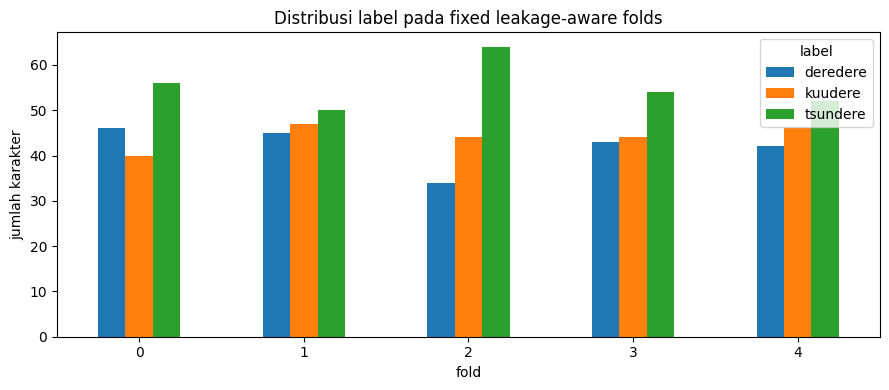

In [16]:
fold_counts = pd.crosstab(train.fold, train.label).reindex(columns=LABELS)
ax = fold_counts.plot(kind='bar', figsize=(9, 4))
ax.set_title('Distribusi label pada fixed leakage-aware folds')
ax.set_xlabel('fold'); ax.set_ylabel('jumlah karakter')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


> ### Insights
> Fold dibuat sekali dan digunakan bersama oleh seluruh branch. Dengan demikian, perbedaan OOF antararsitektur berasal dari model, bukan dari pembagian validasi yang berbeda. Dalam eksperimen lanjutan, fold 2 dan 4 konsisten lebih sulit, sehingga keduanya diperlakukan sebagai sinyal hardness, bukan dibuang sebagai “bad fold”.


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Pemodelan <a name="6"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


Arsitektur final menggunakan **late fusion probabilitas** dari expert dengan objective dan inductive bias berbeda. Text branch sengaja dominan, sedangkan visual branch dibatasi agar berfungsi sebagai evidence pelengkap, bukan mengambil alih keputusan hanya karena satu ekspresi wajah.


## Arsitektur Model

Komponen final:

| Branch | Input | Arsitektur | Peran |
|---|---|---|---|
| TF-IDF | personality | Word/Char TF-IDF + LinearSVC | lexical baseline |
| ConvNeXt | image | WD ConvNeXt V3 + logistic head | baseline visual non-Transformer |
| DeBERTa NLI | personality + visual cues | DeBERTa-v3-large NLI | semantic anchor |
| ModernBERT | personality + name | ModernBERT-large | independent semantic expert |
| EVA02 | image | WD EVA02-Large + logistic head | anime-specific visual evidence |
| SigLIP2 | image | frozen SigLIP2 + logistic head | visual representation diversity |

Pipeline wajib **tanpa Transformer** adalah TF-IDF + WD ConvNeXt CNN. Pipeline final menggunakan Transformer karena hasil eksperimen menunjukkan peningkatan yang jelas dari representasi semantik dan multimodal.


---

## Metrik

Seluruh pemilihan model utama memakai *macro F1-score*. Untuk probabilitas, temperature calibration dipilih berdasarkan log loss OOF agar scale confidence antarbranch lebih sebanding sebelum fusion.


In [17]:
def softmax_np(x):
    x=np.asarray(x,dtype=np.float64); x=x-x.max(axis=1,keepdims=True); ex=np.exp(x); return ex/ex.sum(axis=1,keepdims=True)

def temp_from_logits(oof_logits,y_id,grid=(.5,.75,1.,1.25,1.5,2.)):
    losses={t:log_loss(y_id,softmax_np(oof_logits/t),labels=np.arange(len(LABELS))) for t in grid}
    return min(losses,key=losses.get),losses

def calibrate_prob_temperature(oof_prob,test_prob,y_id,grid=(.5,.75,1.,1.25,1.5,2.)):
    o=np.log(np.clip(oof_prob,1e-10,1)); t=np.log(np.clip(test_prob,1e-10,1))
    T,losses=temp_from_logits(o,y_id,grid)
    return softmax_np(o/T),softmax_np(t/T),T,losses

def make_tfidf_features():
    return FeatureUnion([
        ("word",TfidfVectorizer(analyzer="word",lowercase=True,strip_accents="unicode",ngram_range=(1,2),min_df=2,max_df=.995,max_features=15000 if FAST_DEV_RUN else 50000,sublinear_tf=True,dtype=np.float32)),
        ("char",TfidfVectorizer(analyzer="char_wb",lowercase=True,strip_accents="unicode",ngram_range=(3,5),min_df=2,max_features=20000 if FAST_DEV_RUN else 60000,sublinear_tf=True,dtype=np.float32)),
    ])

def aligned_scores(model,X):
    s=model.decision_function(X)
    out=np.zeros((X.shape[0],len(LABELS)),np.float32)
    for j,c in enumerate(model.classes_): out[:,LABEL2ID[c]]=s[:,j]
    return out

y_id=train.label.map(LABEL2ID).to_numpy(); y_label=train.label.to_numpy()
majority=train.label.value_counts().idxmax()
print("Majority Macro F1:",f1_score(y_label,np.full(len(train),majority),average="macro"))

tfidf_oof_logits=np.zeros((len(train),3),np.float32); tfidf_test_logits_folds=[]; tfidf_scores=[]
for f in range(N_FOLDS):
    tr=np.where(train.fold.to_numpy()!=f)[0]; va=np.where(train.fold.to_numpy()==f)[0]
    v=make_tfidf_features(); Xtr=v.fit_transform(train.personality.iloc[tr].fillna("")); Xva=v.transform(train.personality.iloc[va].fillna("")); Xte=v.transform(test.personality.fillna(""))
    m=LinearSVC(C=1,class_weight="balanced",random_state=SEED+f); m.fit(Xtr,y_label[tr])
    tfidf_oof_logits[va]=aligned_scores(m,Xva); tfidf_test_logits_folds.append(aligned_scores(m,Xte))
    sc=f1_score(y_label[va],np.array(LABELS)[tfidf_oof_logits[va].argmax(1)],average="macro"); tfidf_scores.append(sc); print(f"TF-IDF fold {f}: {sc:.5f}")

TFIDF_TEMP,_=temp_from_logits(tfidf_oof_logits,y_id)
tfidf_oof_prob=softmax_np(tfidf_oof_logits/TFIDF_TEMP)
tfidf_test_prob=np.mean([softmax_np(x/TFIDF_TEMP) for x in tfidf_test_logits_folds],axis=0)
tfidf_f1=f1_score(y_id,tfidf_oof_prob.argmax(1),average="macro")
print(f"TF-IDF OOF Macro F1: {tfidf_f1:.5f} | T={TFIDF_TEMP}")

# Full TF-IDF model for explainability/deployment.
tfidf_full_vec=make_tfidf_features(); Xfull=tfidf_full_vec.fit_transform(train.personality.fillna("")); tfidf_full_clf=LinearSVC(C=1,class_weight="balanced",random_state=SEED); tfidf_full_clf.fit(Xfull,y_label)
joblib.dump({"vectorizer":tfidf_full_vec,"classifier":tfidf_full_clf,"temperature":TFIDF_TEMP},MODEL_DIR/"tfidf_full.joblib")
features=tfidf_full_vec.get_feature_names_out(); rows=[]
for ci,cls in enumerate(tfidf_full_clf.classes_):
    for rank,idx in enumerate(np.argsort(tfidf_full_clf.coef_[ci])[-15:][::-1],1): rows.append({"class":cls,"rank":rank,"feature":features[idx],"coef":float(tfidf_full_clf.coef_[ci,idx])})
display(pd.DataFrame(rows).pivot(index="rank",columns="class",values="feature"))


Majority Macro F1: 0.1871820956256358
TF-IDF fold 0: 0.67775
TF-IDF fold 1: 0.62362
TF-IDF fold 2: 0.53268
TF-IDF fold 3: 0.61995
TF-IDF fold 4: 0.52100
TF-IDF OOF Macro F1: 0.59595 | T=0.5


class,deredere,kuudere,tsundere
rank,,,
1,word__cheerful,word__cold,word__embarrassed
2,word__girl,word__quiet,word__temper
3,word__optimistic,word__stoic,word__but
4,char__hee,word__emotions,word__pride
5,word__happy,word__he was,word__side
6,word__energetic,word__emotion,word__kyoko
7,char__heer,word__emotionless,word__more
8,char__cheer,word__reserved,word__toward
9,char__chee,word__he,word__actually


> ### Insights
> TF-IDF sendiri sudah menangkap kosa kata khas seperti `cheerful`, `cold`, `quiet`, `embarrassed`, dan `temper`. OOF sekitar **0,596** menunjukkan teks mengandung sinyal kuat bahkan tanpa Transformer, tetapi masih jauh dari DeBERTa NLI.


---

## Pipeline Tanpa Transformer: TF-IDF + WD ConvNeXt V3

Pipeline ini memenuhi persyaratan Task #3 bahwa minimal satu solusi tidak boleh menggunakan arsitektur Transformer sama sekali. ConvNeXt adalah CNN, sedangkan TF-IDF dan LinearSVC merupakan metode leksikal/linear.


In [18]:
conv_tags_tr=conv_tags_te=conv_emb_tr=conv_emb_te=conv_tag_names=None
if RUN_CONVNEXT:
    conv_tags_tr,conv_tags_te,conv_emb_tr,conv_emb_te,conv_tag_names=extract_wd_features(CONVNEXT_MODEL_NAME,"wd_convnext_v3_features.npz",(16,8,4,2,1))
    print("ConvNeXt tags/emb:",conv_tags_tr.shape,conv_emb_tr.shape)
else: print("ConvNeXt extraction skipped.")


selected_tags.csv: 0.00B [00:00, ?B/s]

ConvNeXt tags/emb: (707, 8106) (707, 1024)


In [19]:
def cv_image_head(tags_tr,tags_te,emb_tr,emb_te,C=.25,k=512,seed_offset=0):
    oof=np.zeros((len(train),3),np.float32); test_f=[]; scores=[]
    for f in range(N_FOLDS):
        tr=np.where(train.fold.to_numpy()!=f)[0]; va=np.where(train.fold.to_numpy()==f)[0]
        sel=SelectKBest(f_classif,k=min(k,tags_tr.shape[1])); a=sel.fit_transform(tags_tr[tr],y_label[tr]); b=sel.transform(tags_tr[va]); c=sel.transform(tags_te)
        Xtr=np.hstack([a,emb_tr[tr]]); Xva=np.hstack([b,emb_tr[va]]); Xte=np.hstack([c,emb_te])
        sc=StandardScaler(); Xtr=sc.fit_transform(Xtr); Xva=sc.transform(Xva); Xte=sc.transform(Xte)
        m=LogisticRegression(C=C,max_iter=4000,class_weight="balanced",random_state=SEED+seed_offset+f); m.fit(Xtr,y_label[tr])
        rv=m.predict_proba(Xva); rt=m.predict_proba(Xte); pv=np.zeros((len(va),3)); pt=np.zeros((len(test),3))
        for j,cls in enumerate(m.classes_): pv[:,LABEL2ID[cls]]=rv[:,j]; pt[:,LABEL2ID[cls]]=rt[:,j]
        oof[va]=pv; test_f.append(pt); scores.append(f1_score(y_id[va],pv.argmax(1),average="macro"))
    return oof,np.mean(test_f,axis=0),scores

conv_oof_prob=conv_test_prob=None; conv_f1=None
if conv_tags_tr is not None:
    conv_oof_prob,conv_test_prob,conv_scores=cv_image_head(conv_tags_tr,conv_tags_te,conv_emb_tr,conv_emb_te,C=.25,k=512)
    conv_f1=f1_score(y_id,conv_oof_prob.argmax(1),average="macro")
    print("ConvNeXt image folds:",np.round(conv_scores,5),"OOF:",round(conv_f1,5))


ConvNeXt image folds: [0.51833 0.51193 0.53857 0.47857 0.48509] OOF: 0.50862


In [20]:
# Mandatory non-Transformer multimodal fusion.
nontrans_oof=tfidf_oof_prob.copy(); nontrans_test=tfidf_test_prob.copy(); nontrans_weights={"tfidf":1.,"convnext":0.}; nontrans_f1=tfidf_f1
if conv_oof_prob is not None:
    rows=[]
    for wi in np.arange(0,.41,.05):
        p=(1-wi)*tfidf_oof_prob+wi*conv_oof_prob; sc=f1_score(y_id,p.argmax(1),average="macro"); rows.append((sc,1-wi,wi))
    rows.sort(reverse=True); nontrans_f1,wt,wi=rows[0]; nontrans_weights={"tfidf":float(wt),"convnext":float(wi)}
    nontrans_oof=wt*tfidf_oof_prob+wi*conv_oof_prob; nontrans_test=wt*tfidf_test_prob+wi*conv_test_prob
print("Best zero-Transformer fusion:",nontrans_weights,"OOF",round(nontrans_f1,5))


Best zero-Transformer fusion: {'tfidf': 0.75, 'convnext': 0.25} OOF 0.62253


> ### Insights
> Pada run referensi, ConvNeXt image-only memperoleh OOF sekitar **0,504**, sedangkan TF-IDF sekitar **0,596**. Fusion 75% TF-IDF + 25% ConvNeXt naik menjadi sekitar **0,619**. Kenaikan tersebut kecil tetapi menunjukkan bahwa citra membawa informasi tambahan bahkan tanpa Transformer.


---

## WD EVA02-Large: Anime-Specific Visual Expert

EVA02 dipilih karena representasinya berasal dari tagger khusus gambar anime. Head supervised tetap dilatih hanya menggunakan label kompetisi.


In [21]:
eva_tags_tr=eva_tags_te=eva_emb_tr=eva_emb_te=eva_tag_names=None
eva_oof_prob=eva_test_prob=None; eva_f1=None
if RUN_EVA:
    eva_tags_tr,eva_tags_te,eva_emb_tr,eva_emb_te,eva_tag_names=extract_wd_features(EVA_MODEL_NAME,"wd_eva02_large_v3_features.npz",(4,2,1))
    eva_oof_prob,eva_test_prob,eva_scores=cv_image_head(eva_tags_tr,eva_tags_te,eva_emb_tr,eva_emb_te,C=.20,k=512,seed_offset=100)
    eva_f1=f1_score(y_id,eva_oof_prob.argmax(1),average="macro")
    print("EVA image folds:",np.round(eva_scores,5),"OOF:",round(eva_f1,5))
else: print("EVA branch skipped.")


selected_tags.csv: 0.00B [00:00, ?B/s]

EVA image folds: [0.60087 0.54792 0.59668 0.52409 0.52627] OOF: 0.56179


---

## Joint Visual Ablation

ConvNeXt dan EVA juga diuji dalam feature-level maupun probability-level fusion. Tahap ini digunakan untuk memahami visual representation yang paling berguna, bukan untuk mencari rule per-row.


In [22]:
def cv_joint_image(C=.10,k_each=256):
    oof=np.zeros((len(train),3),np.float32); test_f=[]
    for f in range(N_FOLDS):
        tr=np.where(train.fold.to_numpy()!=f)[0]; va=np.where(train.fold.to_numpy()==f)[0]
        s1=SelectKBest(f_classif,k=min(k_each,conv_tags_tr.shape[1])); s2=SelectKBest(f_classif,k=min(k_each,eva_tags_tr.shape[1]))
        a1=s1.fit_transform(conv_tags_tr[tr],y_label[tr]); b1=s1.transform(conv_tags_tr[va]); c1=s1.transform(conv_tags_te)
        a2=s2.fit_transform(eva_tags_tr[tr],y_label[tr]); b2=s2.transform(eva_tags_tr[va]); c2=s2.transform(eva_tags_te)
        Xtr=np.hstack([a1,a2,conv_emb_tr[tr],eva_emb_tr[tr]]); Xva=np.hstack([b1,b2,conv_emb_tr[va],eva_emb_tr[va]]); Xte=np.hstack([c1,c2,conv_emb_te,eva_emb_te])
        sc=StandardScaler(); Xtr=sc.fit_transform(Xtr); Xva=sc.transform(Xva); Xte=sc.transform(Xte)
        m=LogisticRegression(C=C,max_iter=4000,class_weight="balanced",random_state=SEED+200+f); m.fit(Xtr,y_label[tr])
        rv=m.predict_proba(Xva); rt=m.predict_proba(Xte); pv=np.zeros((len(va),3)); pt=np.zeros((len(test),3))
        for j,cls in enumerate(m.classes_): pv[:,LABEL2ID[cls]]=rv[:,j]; pt[:,LABEL2ID[cls]]=rt[:,j]
        oof[va]=pv; test_f.append(pt)
    return oof,np.mean(test_f,axis=0)

joint_oof_prob=joint_test_prob=None; joint_f1=None; JOINT_C=None
if conv_oof_prob is not None and eva_oof_prob is not None:
    candidates=[]
    for C in [.05,.10,.20,.35]:
        o,t=cv_joint_image(C=C); sc=f1_score(y_id,o.argmax(1),average="macro"); candidates.append((sc,C,o,t)); print(f"Joint image C={C}: {sc:.5f}")
    candidates.sort(key=lambda z:z[0],reverse=True); joint_f1,JOINT_C,joint_oof_prob,joint_test_prob=candidates[0]
    print("Best joint image:",JOINT_C,round(joint_f1,5))


Joint image C=0.05: 0.54446
Joint image C=0.1: 0.54593
Joint image C=0.2: 0.54297
Joint image C=0.35: 0.54028
Best joint image: 0.1 0.54593


In [23]:
# Select the strongest calibrated image representation/fusion by OOF.
image_candidates=[]
if conv_oof_prob is not None: image_candidates.append(("convnext",conv_oof_prob,conv_test_prob,f1_score(y_id,conv_oof_prob.argmax(1),average="macro")))
if eva_oof_prob is not None: image_candidates.append(("eva02",eva_oof_prob,eva_test_prob,f1_score(y_id,eva_oof_prob.argmax(1),average="macro")))
if joint_oof_prob is not None: image_candidates.append(("joint",joint_oof_prob,joint_test_prob,f1_score(y_id,joint_oof_prob.argmax(1),average="macro")))
if conv_oof_prob is not None and eva_oof_prob is not None:
    for w in np.arange(0,1.01,.1):
        o=w*eva_oof_prob+(1-w)*conv_oof_prob; t=w*eva_test_prob+(1-w)*conv_test_prob
        image_candidates.append((f"prob_fusion_eva_{w:.1f}",o,t,f1_score(y_id,o.argmax(1),average="macro")))

image_v2_oof=image_v2_test=None; image_v2_name="none"; image_v2_f1=np.nan; IMAGE_TEMP=1.
if image_candidates:
    image_candidates.sort(key=lambda z:z[3],reverse=True); image_v2_name,image_v2_oof,image_v2_test,image_v2_f1=image_candidates[0]
    image_v2_oof,image_v2_test,IMAGE_TEMP,_=calibrate_prob_temperature(image_v2_oof,image_v2_test,y_id)
    print("Selected image V2:",image_v2_name,"OOF",round(image_v2_f1,5),"temperature",IMAGE_TEMP)
    display(pd.DataFrame([{"candidate":n,"oof_macro_f1":s} for n,_,_,s in image_candidates]).sort_values("oof_macro_f1",ascending=False).head(12))


Selected image V2: eva02 OOF 0.56179 temperature 2.0


,candidate,oof_macro_f1
0,eva02,0.561792
1,prob_fusion_eva_1.0,0.561792
2,prob_fusion_eva_0.9,0.558574
3,prob_fusion_eva_0.8,0.551870
4,joint,0.545933
5,prob_fusion_eva_0.7,0.543016
6,prob_fusion_eva_0.6,0.541912
7,prob_fusion_eva_0.5,0.529907
8,prob_fusion_eva_0.4,0.526851
9,prob_fusion_eva_0.3,0.520706


> ### Insights
> EVA02 hanya mencapai OOF sekitar **0,562** sebagai classifier mandiri. Nilai ini jauh di bawah text expert, tetapi eksperimen akhir menunjukkan bahwa standalone F1 tidak sama dengan nilai kondisional sebuah branch di dalam ensemble.


---

## SigLIP2 Visual Representation

SigLIP2 digunakan sebagai frozen image encoder. Embedding dinormalisasi dan classifier logistik dilatih per fold menggunakan label train kompetisi.


In [24]:
siglip_oof_prob=siglip_test_prob=None; siglip_f1=None; SIGLIP_C=None
SIGLIP_CACHE=ARTIFACT_DIR/"siglip2_b16_384_embeddings.npz"

def extract_siglip_embeddings():
    existing=find_input_artifact(SIGLIP_CACHE.name)
    if existing and Path(existing)!=SIGLIP_CACHE and not SIGLIP_CACHE.exists(): shutil.copy2(existing,SIGLIP_CACHE)
    if SIGLIP_CACHE.exists():
        d=np.load(SIGLIP_CACHE)
        if d["train_emb"].shape[0]==len(train) and d["test_emb"].shape[0]==len(test):
            return d["train_emb"].astype(np.float32),d["test_emb"].astype(np.float32)

    import torch
    from transformers import AutoProcessor,AutoModel
    from torch.utils.data import Dataset,DataLoader
    processor=AutoProcessor.from_pretrained(SIGLIP2_MODEL_NAME)
    model=AutoModel.from_pretrained(SIGLIP2_MODEL_NAME).to("cuda:0" if torch.cuda.is_available() else "cpu").eval()
    device=next(model.parameters()).device

    class ImgDS(Dataset):
        def __init__(self,paths): self.paths=list(paths)
        def __len__(self): return len(self.paths)
        def __getitem__(self,i):
            with Image.open(self.paths[i]) as im: return pil_pad_square(pil_ensure_rgb(im)).copy()
    def collate(imgs): return processor(images=imgs,return_tensors="pt")

    ds=ImgDS(list(train.image_path)+list(test.image_path))
    last=None
    for bs in [12,8,4,2,1]:
        try:
            loader=DataLoader(ds,batch_size=bs,shuffle=False,num_workers=2,collate_fn=collate)
            chunks=[]
            with torch.inference_mode():
                for batch in loader:
                    batch={k:v.to(device,non_blocking=True) for k,v in batch.items()}
                    with torch.autocast(device_type="cuda",dtype=torch.float16,enabled=(device.type=="cuda")):
                        e=model.get_image_features(**batch)
                    e=torch.nn.functional.normalize(e.float(),dim=1)
                    chunks.append(e.cpu().numpy())
            emb=np.concatenate(chunks); print("SigLIP2 batch size:",bs); break
        except RuntimeError as exc:
            last=exc
            if "out of memory" not in str(exc).lower(): raise
            clean_cuda(); print("SigLIP2 OOM batch",bs,"-> retry")
    else: raise last
    n=len(train); np.savez_compressed(SIGLIP_CACHE,train_emb=emb[:n].astype(np.float16),test_emb=emb[n:].astype(np.float16))
    del model,processor,loader,ds; clean_cuda()
    return emb[:n],emb[n:]

if RUN_SIGLIP2:
    sig_tr,sig_te=extract_siglip_embeddings()
    candidates=[]
    for C in [.03,.07,.15,.3,.7,1.5]:
        o=np.zeros((len(train),3),np.float32); tf=[]
        for f in range(N_FOLDS):
            tr=np.where(train.fold.to_numpy()!=f)[0]; va=np.where(train.fold.to_numpy()==f)[0]
            sc=StandardScaler(); Xtr=sc.fit_transform(sig_tr[tr]); Xva=sc.transform(sig_tr[va]); Xte=sc.transform(sig_te)
            m=LogisticRegression(C=C,max_iter=4000,class_weight="balanced",random_state=SEED+300+f); m.fit(Xtr,y_label[tr])
            rv=m.predict_proba(Xva); rt=m.predict_proba(Xte); pv=np.zeros((len(va),3)); pt=np.zeros((len(test),3))
            for j,cls in enumerate(m.classes_): pv[:,LABEL2ID[cls]]=rv[:,j]; pt[:,LABEL2ID[cls]]=rt[:,j]
            o[va]=pv; tf.append(pt)
        t=np.mean(tf,axis=0); scv=f1_score(y_id,o.argmax(1),average="macro"); candidates.append((scv,C,o,t)); print(f"SigLIP2 C={C}: {scv:.5f}")
    candidates.sort(key=lambda z:z[0],reverse=True); siglip_f1,SIGLIP_C,siglip_oof_prob,siglip_test_prob=candidates[0]
    siglip_oof_prob,siglip_test_prob,SIGLIP_TEMP,_=calibrate_prob_temperature(siglip_oof_prob,siglip_test_prob,y_id)
    print("Best SigLIP2:",SIGLIP_C,round(siglip_f1,5),"T",SIGLIP_TEMP)
else:
    sig_tr=sig_te=None; SIGLIP_TEMP=1.; print("SigLIP2 skipped.")


SigLIP2 C=0.03: 0.48762
SigLIP2 C=0.07: 0.47334
SigLIP2 C=0.15: 0.47198
SigLIP2 C=0.3: 0.46459
SigLIP2 C=0.7: 0.46573
SigLIP2 C=1.5: 0.46116
Best SigLIP2: 0.03 0.48762 T 2.0


---

## Fold-Safe Visual Cues dan Trait Prototypes

Hanya tag ekspresi/emosi EVA yang boleh masuk ke premise NLI. Tag karakter atau identitas tidak pernah digunakan. Trait prototype dibuat dari training fold dan harus stabil pada inner split, sehingga validation row tidak memengaruhi hipotesisnya sendiri.


In [25]:
TRAIT_NOISE_WORDS=set(ENGLISH_STOP_WORDS)|{
    "character","personality","people","person","girl","girls","boy","boys","friend","friends","series","story","stories",
    "father","mother","school","family","world","life","time","things","thing","someone","others","different","having",
    "strong","short","long","like","likes","does","didn","doesn","act","turn","cause","especially","usually","often",
    "also","sometimes","always","later","eventually","known","called","however","despite","towards","around","make","makes"
}

EMOTION_TAG_WHITELIST={
    "smile","grin","smirk","blush","frown","expressionless","serious","angry","annoyed","pout","crying","tears","sad",
    "happy","laughing","open_mouth","closed_mouth","closed_eyes","half-closed_eyes","looking_away","looking_at_viewer",
    "embarrassed","shy","scared","surprised","confused","nervous","sweat","sweatdrop","furrowed_brow","raised_eyebrow",
    "clenched_teeth","teeth","tongue","wince","sleepy","bored","emotionless","evil_smile","light_smile","wide-eyed"
}

def visual_cue_strings(tags,names,topn=5,threshold=.20):
    if tags is None or names is None: return np.array([""]*(len(train)+len(test)),dtype=object)
    norm=[str(x).strip().lower() for x in names]
    idx=[i for i,n in enumerate(norm) if n in EMOTION_TAG_WHITELIST]
    if not idx: return np.array([""]*tags.shape[0],dtype=object)
    arr=tags[:,idx]; nm=np.array([norm[i] for i in idx],dtype=object)
    out=[]
    for row in arr:
        order=np.argsort(row)[::-1]; chosen=[]
        for j in order:
            if row[j]<threshold: break
            chosen.append(nm[j].replace("_"," "))
            if len(chosen)>=topn: break
        out.append(", ".join(chosen))
    return np.asarray(out,dtype=object)

if eva_tags_tr is not None:
    all_cues=visual_cue_strings(np.vstack([eva_tags_tr,eva_tags_te]),eva_tag_names)
    train["visual_cues"]=all_cues[:len(train)]; test["visual_cues"]=all_cues[len(train):]
else:
    train["visual_cues"]=""; test["visual_cues"]=""
print("Visual-cue coverage train/test:",(train.visual_cues!="").mean(),(test.visual_cues!="").mean())
display(train.loc[train.visual_cues!="",["character_name","visual_cues"]].head(10))

def _candidate_terms(indices,top_per_class=45):
    texts=train.personality.iloc[indices].fillna("")
    v=TfidfVectorizer(lowercase=True,strip_accents="unicode",ngram_range=(1,2),min_df=3,max_df=.97,max_features=30000,sublinear_tf=True,stop_words="english")
    X=v.fit_transform(texts); m=LinearSVC(C=.8,class_weight="balanced",random_state=SEED); m.fit(X,y_label[indices]); names=v.get_feature_names_out(); df=np.asarray((X>0).sum(0)).ravel()
    name_tokens=set()
    for nm in train.character_name.iloc[indices].fillna(""):
        name_tokens.update(re.findall(r"[a-z]{3,}",str(nm).lower()))
    out={c:[] for c in LABELS}
    for ci,cls in enumerate(m.classes_):
        for j in np.argsort(m.coef_[ci])[::-1]:
            feat=names[j].strip(); toks=feat.split()
            if df[j]<5 or len(toks)>2 or not re.fullmatch(r"[a-z][a-z\- ]+",feat): continue
            if any(len(t)<3 or t in TRAIT_NOISE_WORDS or t in name_tokens for t in toks): continue
            out[cls].append(feat)
            if len(out[cls])>=top_per_class: break
    return out

def stable_trait_prototypes(indices,topk=9):
    indices=np.asarray(indices); yy=y_id[indices]
    inner=StratifiedKFold(n_splits=3,shuffle=True,random_state=SEED+711)
    counts={c:{} for c in LABELS}
    for _,subtr_local in inner.split(indices,yy):
        terms=_candidate_terms(indices[subtr_local])
        for c in LABELS:
            for rank,t in enumerate(terms[c]): counts[c][t]=counts[c].get(t,0)+(1 if rank<30 else .5)
    full=_candidate_terms(indices,top_per_class=80); out={}
    for c in LABELS:
        stable=[t for t in full[c] if counts[c].get(t,0)>=2]
        if len(stable)<topk: stable += [t for t in full[c] if t not in stable]
        out[c]=stable[:topk]
    return out

HYP_TEMPLATES=[
    "This character fits the {cls} archetype; the training data associates it with traits such as {traits}.",
    "The described personality is consistent with {cls}, with signals such as {traits}.",
    "This is a {cls} character. Relevant personality cues include {traits}.",
]

def make_hypothesis(cls,traits,template_id=0):
    return HYP_TEMPLATES[template_id%len(HYP_TEMPLATES)].format(cls=cls,traits=", ".join(traits))

def make_premise(df,i,with_visual=True):
    name=str(df.character_name.iloc[i]); pers=str(df.personality.iloc[i])
    cue=str(df.visual_cues.iloc[i]) if "visual_cues" in df.columns else ""
    s=f"Character: {name}. Personality: {pers}"
    if with_visual and cue: s += f" Visual cues from the character image: {cue}."
    return s

full_traits=stable_trait_prototypes(np.arange(len(train)))
print("Stable full-train prototypes (for final deploy only):")
for c in LABELS: print(c,"=>",full_traits[c])


Visual-cue coverage train/test: 0.9547383309759547 0.956953642384106


,character_name,visual_cues
0,Ritsu Tainaka,open mouth
1,"Suelecia ""Sue"" Zagan Analeit","looking at viewer, closed mouth, smile"
2,Fate Testarossa,"looking at viewer, smile, open mouth"
4,Italy,"open mouth, closed eyes, blush, smile, happy"
5,Ai Miyashita,"open mouth, smile, looking at viewer"
6,Seijuurou Akashi,"looking at viewer, smile, closed mouth, light ..."
7,Yoshida Yuuko / Shamiko,"blush, looking at viewer, open mouth"
8,Yukine,"open mouth, smile, looking at viewer"
9,Akuru Akutsu,"sweatdrop, looking at viewer, open mouth"
10,Misaki Tokura,"smile, closed mouth, looking at viewer"


Stable full-train prototypes (for final deploy only):
deredere => ['cheerful', 'optimistic', 'energetic', 'happy', 'carefree', 'loving', 'positive', 'loves', 'childish']
kuudere => ['cold', 'quiet', 'stoic', 'emotions', 'emotion', 'emotionless', 'reserved', 'rarely', 'calm']
tsundere => ['embarrassed', 'pride', 'actually', 'seriously', 'comes', 'temper', 'seeing', 'usagi', 'stubborn']


---

## Runtime Guard ModernBERT pada T4 x2

ModernBERT mempunyai jalur `reference_compile` yang tidak kompatibel dengan DataParallel tertentu. Smoke test dua GPU dijalankan **sebelum** training mahal agar notebook gagal cepat jika runtime tidak sesuai.


In [26]:
if RUN_MODERNBERT:
    import torch
    from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification

    def load_modernbert_classifier():
        cfg = AutoConfig.from_pretrained(
            MODERNBERT_MODEL_NAME,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            reference_compile=False,
        )
        cfg.reference_compile = False
        return AutoModelForSequenceClassification.from_pretrained(
            MODERNBERT_MODEL_NAME,
            config=cfg,
            ignore_mismatched_sizes=True,
        )

    _smoke_tok = AutoTokenizer.from_pretrained(MODERNBERT_MODEL_NAME)
    _smoke_model = load_modernbert_classifier()
    _smoke_model.train()
    _smoke_batch = _smoke_tok(
        ["A cheerful and affectionate character.", "A quiet and emotionally reserved character."],
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt",
    )
    _smoke_labels = torch.tensor([0, 1], dtype=torch.long)
    if torch.cuda.is_available():
        _smoke_model = _smoke_model.cuda()
        _smoke_batch = {k: v.cuda() for k, v in _smoke_batch.items()}
        _smoke_labels = _smoke_labels.cuda()
    _runner = torch.nn.DataParallel(_smoke_model) if torch.cuda.is_available() and torch.cuda.device_count() > 1 else _smoke_model
    _out = _runner(**_smoke_batch, labels=_smoke_labels)
    _out.loss.mean().backward()
    print("ModernBERT DataParallel smoke test: PASS")
    del _out, _runner, _smoke_model, _smoke_batch, _smoke_labels, _smoke_tok
    clean_cuda()
else:
    print("ModernBERT runtime smoke test skipped in FAST_DEV_RUN.")


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ModernBERT DataParallel smoke test: PASS


---

## DeBERTa-v3-large NLI

Setiap karakter dibentuk menjadi tiga pasangan premise-hypothesis, satu untuk masing-masing archetype. Label benar dilatih sebagai `entailment`, sedangkan dua kelas lain sebagai `not_entailment`. Head NLI pretrained dipertahankan.

Pendekatan ini dipilih karena dataset kecil. Alih-alih meminta model mempelajari arti tiga label dari nol, formulasi NLI memanfaatkan pengetahuan semantik yang sudah terdapat pada checkpoint pretrained.


In [27]:
nli_variant_oof={}; nli_variant_test={}; nli_variant_scores={}; nli_variant_best_epochs={}; nli_large_oof_prob=nli_large_test_prob=None; nli_large_f1=None; NLI_LARGE_TEMP=1.

if RUN_NLI_LARGE:
    import torch, torch.nn.functional as F
    from torch.utils.data import Dataset
    from transformers import AutoTokenizer,AutoModelForSequenceClassification,DataCollatorWithPadding,Trainer,TrainingArguments,EarlyStoppingCallback

    nli_tok=AutoTokenizer.from_pretrained(NLI_LARGE_MODEL_NAME)
    cfg=AutoModelForSequenceClassification.from_pretrained(NLI_LARGE_MODEL_NAME).config
    entail_id=int(cfg.label2id.get("entailment",0)); not_id=int(cfg.label2id.get("not_entailment",1))
    del cfg; clean_cuda()
    print("NLI IDs entail/not:",entail_id,not_id)

    class PairDS(Dataset):
        def __init__(self,df,indices,traits,training=False,template_id=0,seed=0):
            self.df=df; self.indices=list(map(int,indices)); self.traits=traits; self.training=training; self.template_id=template_id; self.seed=seed
        def __len__(self): return len(self.indices)*3
        def __getitem__(self,k):
            pos=k//3; clsid=k%3; i=self.indices[pos]; cls=LABELS[clsid]
            tid=(i+clsid+self.seed)%len(HYP_TEMPLATES) if self.training else self.template_id
            premise=make_premise(self.df,i,with_visual=True); hyp=make_hypothesis(cls,self.traits[cls],tid)
            enc=nli_tok(premise,hyp,truncation="only_first",max_length=NLI_MAXLEN)
            if self.df is train:
                true=LABEL2ID[self.df.label.iloc[i]]; enc["labels"]=entail_id if clsid==true else not_id
            return enc

    coll=DataCollatorWithPadding(nli_tok,pad_to_multiple_of=8)
    def nli_metrics(ep):
        logits,lab=ep; logits=np.asarray(logits); lab=np.asarray(lab).reshape(-1,3)
        sc=(logits[:,entail_id]-logits[:,not_id]).reshape(-1,3); yt=(lab==entail_id).argmax(1); yp=sc.argmax(1)
        return {"macro_f1":f1_score(yt,yp,average="macro")}

    class NLITrainer(Trainer):
        def compute_loss(self,model,inputs,return_outputs=False,num_items_in_batch=None):
            labels=inputs.pop("labels"); out=model(**inputs); weights=torch.ones(out.logits.shape[-1],device=out.logits.device,dtype=out.logits.dtype); weights[entail_id]=2.0
            loss=F.cross_entropy(out.logits,labels,weight=weights,label_smoothing=.02)
            return (loss,out) if return_outputs else loss

    def predict_nli_templates(trainer,df,indices,traits):
        all_scores=[]
        for tid in range(len(HYP_TEMPLATES)):
            ds=PairDS(df,indices,traits,training=False,template_id=tid)
            lg=trainer.predict(ds).predictions
            sc=(lg[:,entail_id]-lg[:,not_id]).reshape(len(indices),3); all_scores.append(sc)
        return np.mean(all_scores,axis=0)

    for variant in NLI_VARIANTS:
        name=variant["name"]; seed=variant["seed"]; oof_score=np.zeros((len(train),3),np.float32); test_scores=[]; fs=[]; best_epochs=[]
        print("\n===",name,"===")
        for f in range(N_FOLDS):
            tr=np.where(train.fold.to_numpy()!=f)[0]; va=np.where(train.fold.to_numpy()==f)[0]; traits=stable_trait_prototypes(tr)
            model=AutoModelForSequenceClassification.from_pretrained(NLI_LARGE_MODEL_NAME)
            if variant["freeze_bottom"]>0:
                try:
                    for p in model.deberta.embeddings.parameters(): p.requires_grad=False
                    for layer in model.deberta.encoder.layer[:variant["freeze_bottom"]]:
                        for p in layer.parameters(): p.requires_grad=False
                except Exception as exc: print("Layer freeze unavailable:",exc)
            outdir=MODEL_DIR/f"_{name}_fold{f}"; shutil.rmtree(outdir,ignore_errors=True)
            use_ckpt=torch.cuda.device_count()<=1
            args=TrainingArguments(
                output_dir=str(outdir),overwrite_output_dir=True,learning_rate=variant["lr"],num_train_epochs=NLI_EPOCHS,
                per_device_train_batch_size=1,per_device_eval_batch_size=4,gradient_accumulation_steps=4,weight_decay=.015,warmup_ratio=.10,
                lr_scheduler_type="linear",fp16=torch.cuda.is_available(),gradient_checkpointing=use_ckpt,
                gradient_checkpointing_kwargs={"use_reentrant":False} if use_ckpt else None,
                eval_strategy="epoch",save_strategy="epoch",save_only_model=True,logging_strategy="epoch",load_best_model_at_end=True,
                metric_for_best_model="macro_f1",greater_is_better=True,save_total_limit=1,report_to="none",seed=seed+f,data_seed=seed+f,
                dataloader_num_workers=2,eval_accumulation_steps=8,optim="adamw_torch",ddp_find_unused_parameters=False,ddp_broadcast_buffers=False,
            )
            trds=PairDS(train,tr,traits,training=True,seed=seed+f); vads=PairDS(train,va,traits,training=False,template_id=0)
            trainer=NLITrainer(model=model,args=args,train_dataset=trds,eval_dataset=vads,data_collator=coll,compute_metrics=nli_metrics,callbacks=[EarlyStoppingCallback(early_stopping_patience=1)])
            trainer.train()
            sva=predict_nli_templates(trainer,train,va,traits); ste=predict_nli_templates(trainer,test,np.arange(len(test)),traits)
            oof_score[va]=sva; test_scores.append(ste); pred=sva.argmax(1); sc=f1_score(y_id[va],pred,average="macro"); fs.append(sc)
            hist=[x for x in trainer.state.log_history if "eval_macro_f1" in x]; best=max(hist,key=lambda x:x["eval_macro_f1"]) if hist else {"epoch":NLI_EPOCHS}; best_epochs.append(int(max(1,round(float(best.get("epoch",NLI_EPOCHS))))))
            print(f"{name} fold {f}: {sc:.5f} | epoch {best_epochs[-1]} | free {disk_free_gb():.1f} GB | {elapsed_h():.2f}h")
            del trainer,model,trds,vads; shutil.rmtree(outdir,ignore_errors=True); clean_cuda()
        T,_=temp_from_logits(oof_score,y_id,grid=(.5,.75,1.,1.25,1.5,1.75,2.))
        po=softmax_np(oof_score/T); pt=np.mean([softmax_np(x/T) for x in test_scores],axis=0)
        nli_variant_oof[name]=po; nli_variant_test[name]=pt; nli_variant_scores[name]=f1_score(y_id,po.argmax(1),average="macro"); nli_variant_best_epochs[name]=best_epochs
        print(name,"folds",np.round(fs,5),"OOF",round(nli_variant_scores[name],5),"T",T)
        np.save(ARTIFACT_DIR/f"{name}_oof_prob.npy",po.astype(np.float32))
        np.save(ARTIFACT_DIR/f"{name}_test_prob.npy",pt.astype(np.float32))

    nli_large_oof_prob=np.mean(list(nli_variant_oof.values()),axis=0); nli_large_test_prob=np.mean(list(nli_variant_test.values()),axis=0)
    nli_large_oof_prob,nli_large_test_prob,NLI_LARGE_TEMP,_=calibrate_prob_temperature(nli_large_oof_prob,nli_large_test_prob,y_id,grid=(.6,.8,1.,1.2,1.5,1.8))
    nli_large_f1=f1_score(y_id,nli_large_oof_prob.argmax(1),average="macro")
    print("NLI-large stabilized OOF:",round(nli_large_f1,5),"T",NLI_LARGE_TEMP)
else:
    print("NLI-large skipped in FAST_DEV_RUN.")


tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

...

nli_large_full fold 2: 0.69759 | epoch 1 | free 17.8 GB | 1.32h


Epoch,Training Loss,Validation Loss,Macro F1
1,0.544600,0.414690,0.739575
2,0.388500,0.482267,0.737340


nli_large_full fold 3: 0.73898 | epoch 1 | free 17.8 GB | 1.75h


Epoch,Training Loss,Validation Loss,Macro F1
1,0.522200,0.551110,0.687401
2,0.354700,0.629004,0.699251


nli_large_full fold 4: 0.71406 | epoch 2 | free 17.8 GB | 2.18h
nli_large_full folds [0.77763 0.82023 0.69759 0.73898 0.71406] OOF 0.75186 T 2.0
NLI-large stabilized OOF: 0.75186 T 1.2


> ### Insights
> Pada run referensi, DeBERTa NLI memperoleh OOF **0,74949**, jauh di atas TF-IDF dan semua visual branch. Hal ini mengonfirmasi bahwa masalah Dere Detector terutama merupakan persoalan semantik kepribadian.


---

## ModernBERT-large

ModernBERT dilatih sebagai klasifikasi tiga kelas langsung menggunakan dua view: `personality` serta `character_name + personality`. Pada validasi dan test, probabilitas kedua view dirata-ratakan.


In [28]:
modern_oof_prob=modern_test_prob=None; modern_f1=None; MODERN_TEMP=1.; modern_best_epochs=[]
if RUN_MODERNBERT:
    import torch
    from torch.utils.data import Dataset
    from transformers import AutoTokenizer,AutoModelForSequenceClassification,DataCollatorWithPadding,Trainer,TrainingArguments,EarlyStoppingCallback
    modern_tok=AutoTokenizer.from_pretrained(MODERNBERT_MODEL_NAME)

    def view_text(df,i,mode):
        p=str(df.personality.iloc[i]); n=str(df.character_name.iloc[i])
        return p if mode==0 else f"Character: {n}. Personality: {p}"

    class ModernDS(Dataset):
        def __init__(self,df,indices,duplicate_views=False,view=0): self.df=df; self.indices=list(map(int,indices)); self.dup=duplicate_views; self.view=view
        def __len__(self): return len(self.indices)*(2 if self.dup else 1)
        def __getitem__(self,k):
            if self.dup: pos=k//2; mode=k%2
            else: pos=k; mode=self.view
            i=self.indices[pos]; enc=modern_tok(view_text(self.df,i,mode),truncation=True,max_length=MODERN_MAXLEN)
            if self.df is train: enc["labels"]=LABEL2ID[self.df.label.iloc[i]]
            return enc
    coll=DataCollatorWithPadding(modern_tok,pad_to_multiple_of=8)
    def metrics(ep):
        lg,lab=ep; return {"macro_f1":f1_score(lab,np.asarray(lg).argmax(1),average="macro")}
    def predict_views(trainer,df,indices):
        ps=[]
        for mode in [0,1]: ps.append(softmax_np(trainer.predict(ModernDS(df,indices,view=mode)).predictions))
        return np.mean(ps,axis=0)

    oof=np.zeros((len(train),3),np.float32); tf=[]; fs=[]
    for f in range(N_FOLDS):
        tr=np.where(train.fold.to_numpy()!=f)[0]; va=np.where(train.fold.to_numpy()==f)[0]
        model=load_modernbert_classifier()
        outdir=MODEL_DIR/f"_modern_fold{f}"; shutil.rmtree(outdir,ignore_errors=True)
        use_ckpt=torch.cuda.device_count()<=1
        args=TrainingArguments(
            output_dir=str(outdir),overwrite_output_dir=True,learning_rate=1.0e-5,num_train_epochs=MODERN_EPOCHS,
            per_device_train_batch_size=1,per_device_eval_batch_size=4,gradient_accumulation_steps=4,weight_decay=.02,warmup_ratio=.10,
            lr_scheduler_type="linear",fp16=torch.cuda.is_available(),gradient_checkpointing=use_ckpt,
            gradient_checkpointing_kwargs={"use_reentrant":False} if use_ckpt else None,eval_strategy="epoch",save_strategy="epoch",save_only_model=True,
            logging_strategy="epoch",load_best_model_at_end=True,metric_for_best_model="macro_f1",greater_is_better=True,save_total_limit=1,
            label_smoothing_factor=.04,report_to="none",seed=SEED+4000+f,data_seed=SEED+4000+f,dataloader_num_workers=2,
            eval_accumulation_steps=8,optim="adamw_torch",ddp_find_unused_parameters=False,ddp_broadcast_buffers=False,
        )
        trds=ModernDS(train,tr,duplicate_views=True); vads=ModernDS(train,va,view=1)
        trainer=Trainer(model=model,args=args,train_dataset=trds,eval_dataset=vads,data_collator=coll,compute_metrics=metrics,callbacks=[EarlyStoppingCallback(early_stopping_patience=1)])
        trainer.train(); pv=predict_views(trainer,train,va); pt=predict_views(trainer,test,np.arange(len(test)))
        oof[va]=pv; tf.append(pt); sc=f1_score(y_id[va],pv.argmax(1),average="macro"); fs.append(sc)
        hist=[x for x in trainer.state.log_history if "eval_macro_f1" in x]; best=max(hist,key=lambda x:x["eval_macro_f1"]) if hist else {"epoch":MODERN_EPOCHS}; modern_best_epochs.append(int(max(1,round(float(best.get("epoch",MODERN_EPOCHS))))))
        print(f"ModernBERT fold {f}: {sc:.5f} | epoch {modern_best_epochs[-1]} | free {disk_free_gb():.1f} GB | {elapsed_h():.2f}h")
        del trainer,model,trds,vads; shutil.rmtree(outdir,ignore_errors=True); clean_cuda()
    modern_test_prob=np.mean(tf,axis=0); modern_oof_prob=oof
    modern_oof_prob,modern_test_prob,MODERN_TEMP,_=calibrate_prob_temperature(modern_oof_prob,modern_test_prob,y_id,grid=(.6,.8,1.,1.2,1.5,1.8))
    modern_f1=f1_score(y_id,modern_oof_prob.argmax(1),average="macro")
    print("ModernBERT folds",np.round(fs,5),"OOF",round(modern_f1,5),"T",MODERN_TEMP)
    np.save(ARTIFACT_DIR/"modernbert_oof_prob.npy",modern_oof_prob.astype(np.float32))
    np.save(ARTIFACT_DIR/"modernbert_test_prob.npy",modern_test_prob.astype(np.float32))
else:
    print("ModernBERT skipped in FAST_DEV_RUN.")


Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,9.027000,2.178982,0.352578
2,6.353800,1.310414,0.735904
3,2.927200,1.442838,0.706840


ModernBERT fold 0: 0.71455 | epoch 2 | free 18.0 GB | 2.47h


Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,8.192400,1.731827,0.631187
2,3.090300,1.528411,0.705962
3,1.324500,1.366281,0.782585


...

Epoch,Training Loss,Validation Loss,Macro F1
1,8.482200,1.488024,0.710438
2,3.253500,1.239923,0.733434
3,1.307200,1.221278,0.722202


ModernBERT fold 3: 0.75557 | epoch 2 | free 18.0 GB | 3.34h


Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,8.249400,2.184978,0.406022
2,3.249400,1.918504,0.643888
3,1.344700,1.793370,0.663805


ModernBERT fold 4: 0.66438 | epoch 3 | free 18.0 GB | 3.63h
ModernBERT folds [0.71455 0.79673 0.60833 0.75557 0.66438] OOF 0.70843 T 1.2


> ### Insights
> ModernBERT OOF sekitar **0,72017**, di bawah DeBERTa NLI tetapi cukup kuat dan memiliki pola kesalahan berbeda. Peran utamanya adalah menambah **representation diversity**, bukan menggantikan NLI anchor.


---

## Anchor Eksperimen Lama

Artifact V1/V2 hanya digunakan sebagai diagnostic anchor apabila tersedia. Seluruh final V3 tetap self-contained dan tidak membutuhkan label eksternal.


In [29]:
legacy_oof={}; legacy_test={}; v1_oof_prob=None; v1_test_pred_hard=None

def load_prob_pair(name,stem):
    a=find_input_artifact(stem+"_oof_prob.npy"); b=find_input_artifact(stem+"_test_prob.npy")
    if a and b:
        o=np.load(a); t=np.load(b)
        if o.shape==(len(train),3) and t.shape==(len(test),3): legacy_oof[name]=o.astype(float); legacy_test[name]=t.astype(float); print("Loaded legacy",name)

load_prob_pair("nli_base","nli_ft")
load_prob_pair("deberta_base","deberta")

v1csv=find_input_artifact("final_oof_predictions.csv"); v1sub=find_input_artifact("submission_strong_baseline.csv")
if v1csv and v1sub:
    d=pd.read_csv(v1csv); cols=[f"final_prob_{c}" for c in LABELS]
    if set(cols).issubset(d.columns):
        d=d.set_index("character_id").loc[train.character_id]
        v1_oof_prob=d[cols].to_numpy(float); v1_oof_sc=f1_score(y_id,v1_oof_prob.argmax(1),average="macro")
        s=pd.read_csv(v1sub).set_index("character_id").loc[test.character_id]
        if set(s.label).issubset(set(LABELS)): v1_test_pred_hard=s.label.to_numpy(); print("Loaded V1 anchor OOF",round(v1_oof_sc,5))


Loaded legacy nli_base
Loaded legacy deberta_base
Loaded V1 anchor OOF 0.73683


---

## Perbandingan Arsitektur dan Complementarity

Standalone F1 bukan satu-satunya ukuran nilai sebuah expert. Tabel berikut membandingkan OOF tiap branch dan menghitung berapa banyak error DeBERTa yang dapat diselamatkan oleh expert lain.


In [30]:
branch_oof={"tfidf":tfidf_oof_prob}; branch_test={"tfidf":tfidf_test_prob}
if conv_oof_prob is not None: branch_oof["convnext"]=conv_oof_prob; branch_test["convnext"]=conv_test_prob
if eva_oof_prob is not None: branch_oof["eva02"]=eva_oof_prob; branch_test["eva02"]=eva_test_prob
if siglip_oof_prob is not None: branch_oof["siglip2"]=siglip_oof_prob; branch_test["siglip2"]=siglip_test_prob
if nli_large_oof_prob is not None: branch_oof["nli_large"]=nli_large_oof_prob; branch_test["nli_large"]=nli_large_test_prob
if modern_oof_prob is not None: branch_oof["modernbert"]=modern_oof_prob; branch_test["modernbert"]=modern_test_prob
for n,p in legacy_oof.items(): branch_oof[n]=p; branch_test[n]=legacy_test[n]

rows=[]
for n,p in branch_oof.items(): rows.append({"branch":n,"oof_macro_f1":f1_score(y_id,p.argmax(1),average="macro")})
arch=pd.DataFrame(rows).sort_values("oof_macro_f1",ascending=False); display(arch)
arch.to_csv(ARTIFACT_DIR/"architecture_comparison_v3.csv",index=False)

pred_matrix=np.stack([p.argmax(1) for p in branch_oof.values()],axis=1)
oracle=(pred_matrix==y_id[:,None]).any(1)
print(f"At-least-one-expert oracle coverage: {oracle.mean():.2%} ({oracle.sum()}/{len(train)})")
if "nli_large" in branch_oof:
    for n,p in branch_oof.items():
        if n=="nli_large": continue
        a=branch_oof["nli_large"].argmax(1); b=p.argmax(1)
        print(f"{n:14s} rescues NLI-large:",int(((a!=y_id)&(b==y_id)).sum()),"| NLI-large rescues:",int(((a==y_id)&(b!=y_id)).sum()))


,branch,oof_macro_f1
4,nli_large,0.751859
6,nli_base,0.729659
7,deberta_base,0.711609
5,modernbert,0.708426
0,tfidf,0.595948
2,eva02,0.561792
1,convnext,0.508620
3,siglip2,0.487622


At-least-one-expert oracle coverage: 98.30% (695/707)
tfidf          rescues NLI-large: 68 | NLI-large rescues: 178
convnext       rescues NLI-large: 75 | NLI-large rescues: 247
eva02          rescues NLI-large: 89 | NLI-large rescues: 226
siglip2        rescues NLI-large: 77 | NLI-large rescues: 265
modernbert     rescues NLI-large: 66 | NLI-large rescues: 97
nli_base       rescues NLI-large: 45 | NLI-large rescues: 60
deberta_base   rescues NLI-large: 57 | NLI-large rescues: 86


> ### Insights
> Pada run V3.2, setidaknya satu expert memprediksi benar pada **696 dari 707 karakter (98,44%)**. Ini menunjukkan bahwa bottleneck utama setelah representasi cukup beragam bukan lagi “apakah ada model yang tahu jawaban”, melainkan bagaimana menggabungkan evidence tanpa overfitting.


---

## Constrained, Stability-Aware Fusion

Pencarian weight dibatasi dengan prior text-dominant dan hard cap untuk branch lemah. Weight dipilih secara cross-fitted, kemudian median fold di-*shrink* kembali menuju prior agar keputusan deployment tidak mengikuti satu fold secara berlebihan.


In [31]:
def macro(yt,yp): return f1_score(yt,yp,average="macro")

def _prior(names):
    base={"nli_large":.55,"modernbert":.27,"nli_base":.08,"deberta_base":.04,"tfidf":.03,"eva02":.02,"siglip2":.01}
    x=np.array([base.get(n,0.01) for n in names],float); return x/x.sum()

def weight_candidates(names,n=2200,seed=SEED+8800):
    if len(names)==1: return np.ones((1,1))
    rng=np.random.default_rng(seed); pr=_prior(names); alpha=1+12*pr; W=rng.dirichlet(alpha,size=n)
    caps={"nli_large":.82,"modernbert":.55,"nli_base":.22,"deberta_base":.18,"tfidf":.14,"eva02":.14,"siglip2":.10}
    keep=np.ones(len(W),bool)
    for j,nm in enumerate(names): keep &= W[:,j]<=caps.get(nm,.20)
    weak=[j for j,nm in enumerate(names) if nm in {"tfidf","eva02","siglip2","convnext"}]
    if weak: keep &= W[:,weak].sum(1)<=.22
    W=W[keep]
    extras=[pr]
    for nli_w in [.5,.6,.7]:
        if "nli_large" in names and "modernbert" in names:
            x=np.zeros(len(names)); x[names.index("nli_large")]=nli_w; x[names.index("modernbert")]=1-nli_w; extras.append(x)
    return np.vstack([W,np.asarray(extras)])

def blend(names,w,test=False,mask=None):
    src=branch_test if test else branch_oof; out=None
    for nm,ww in zip(names,w):
        p=src[nm] if mask is None else src[nm][mask]
        out=ww*p if out is None else out+ww*p
    return out

def bias_search(p,yy):
    lp=np.log(np.clip(p,1e-12,1)); best=(-1,np.zeros(3))
    for a in [-.08,-.04,0,.04,.08]:
        for b in [-.08,-.04,0,.04,.08]:
            bi=np.array([a,b,0.]); sc=macro(yy,(lp+bi).argmax(1))
            if sc>best[0]: best=(sc,bi)
    return best

def crossfit_constrained(names):
    cand=weight_candidates(names,500 if FAST_DEV_RUN else 2200); op=np.zeros((len(train),3)); oy=np.zeros(len(train),int); selected=[]
    folds=train.fold.to_numpy()
    for f in range(N_FOLDS):
        tr=folds!=f; va=~tr; best=(-1,None)
        for w in cand:
            p=blend(names,w,mask=tr); sc=macro(y_id[tr],p.argmax(1))
            if sc>best[0]: best=(sc,w.copy())
        w=best[1]; ptr=blend(names,w,mask=tr); _,b=bias_search(ptr,y_id[tr]); pva=blend(names,w,mask=va); pred=(np.log(np.clip(pva,1e-12,1))+b).argmax(1)
        op[va]=pva; oy[va]=pred; selected.append((f,w,b,best[0],macro(y_id[va],pred)))
    W=np.stack([x[1] for x in selected]); med=np.median(W,axis=0); med=med/med.sum(); instability=float(W.std(axis=0).mean()); shrink=.45 if instability>.08 else .30
    prior=_prior(names); final=(1-shrink)*med+shrink*prior; final=final/final.sum(); B=np.median(np.stack([x[2] for x in selected]),axis=0)
    return {"names":names,"oof_pred":oy,"oof_prob":op,"honest_f1":macro(y_id,oy),"selected":selected,"raw_weights":W,"instability":instability,"shrink":shrink,"weights":final,"bias":B}

CORE_NAMES=[n for n in ["nli_large","modernbert","tfidf","eva02","siglip2"] if n in branch_oof]
TEXT_NAMES=[n for n in ["nli_large","modernbert"] if n in branch_oof]
if len(CORE_NAMES)<2: CORE_NAMES=[n for n in ["tfidf","eva02","siglip2"] if n in branch_oof]
if not TEXT_NAMES: TEXT_NAMES=[n for n in ["tfidf"] if n in branch_oof]

main_meta=crossfit_constrained(CORE_NAMES); text_meta=crossfit_constrained(TEXT_NAMES)
print("V3 main honest meta OOF:",round(main_meta["honest_f1"],5))
print("V3 main deployment weights:",dict(zip(CORE_NAMES,np.round(main_meta["weights"],4))),"instability",round(main_meta["instability"],4),"shrink",main_meta["shrink"])
print("V3 text honest meta OOF:",round(text_meta["honest_f1"],5))

def deploy(meta):
    p=blend(meta["names"],meta["weights"],test=True); pred=(np.log(np.clip(p,1e-12,1))+meta["bias"]).argmax(1); return p,np.array(LABELS)[pred]
main_test_prob,main_test_pred=deploy(main_meta); text_test_prob,text_test_pred=deploy(text_meta)
fixed_oof=blend(CORE_NAMES,main_meta["weights"]); fixed_pred=(np.log(np.clip(fixed_oof,1e-12,1))+main_meta["bias"]).argmax(1)
print("Fixed deployment-weight OOF diagnostic:",round(macro(y_id,fixed_pred),5))
display(pd.DataFrame([{"fold":f,**{f"w_{n}":w[i] for i,n in enumerate(CORE_NAMES)},"heldout_f1":va} for f,w,b,tr,va in main_meta["selected"]]))


V3 main honest meta OOF: 0.73933
V3 main deployment weights: {'nli_large': np.float64(0.5773), 'modernbert': np.float64(0.271), 'tfidf': np.float64(0.0501), 'eva02': np.float64(0.0912), 'siglip2': np.float64(0.0105)} instability 0.0547 shrink 0.3
V3 text honest meta OOF: 0.75147
Fixed deployment-weight OOF diagnostic: 0.75641


,fold,w_nli_large,w_modernbert,w_tfidf,w_eva02,w_siglip2,heldout_f1
0,0,0.562231,0.258192,0.057443,0.121650,0.000484,0.785455
1,1,0.562529,0.224546,0.047258,0.139692,0.025976,0.819162
2,2,0.512622,0.343031,0.100256,0.034313,0.009778,0.660895
3,3,0.796171,0.073067,0.074137,0.046453,0.010173,0.759758
4,4,0.526107,0.295072,0.029650,0.125508,0.023664,0.666647


> ### Insights
> V3 main memberi bobot terbesar pada DeBERTa NLI dan ModernBERT. TF-IDF, EVA02, dan SigLIP2 tetap mendapat bobot kecil karena fungsi utamanya adalah memberi evidence berbeda ketika text expert tidak sepakat.


---

## Diagnostic: Selective Override dan Nonlinear Stacker

Dua eksperimen berikut dipertahankan sebagai dokumentasi. Keduanya **bukan** arsitektur final karena keputusan per-row dan second-level model mempunyai risiko overfit lebih tinggi pada 707 sampel.


In [32]:
selective_oof_pred=None; selective_test_pred=None; selective_f1=None; selective_settings=None

def apply_selective_override(anchor_pred, challenger_pred, support_pred, challenger_conf, support_conf, challenger_margin, support_margin, conf_thr, margin_thr, transition_stats):
    out=np.asarray(anchor_pred).copy()
    for i in range(len(out)):
        a=int(anchor_pred[i]); b=int(challenger_pred[i])
        if b!=a and int(support_pred[i])==b and challenger_conf[i]>=conf_thr and support_conf[i]>=conf_thr and challenger_margin[i]>=margin_thr and support_margin[i]>=margin_thr:
            rate,n=transition_stats.get((a,b),(0,0))
            if n>=6 and rate>=.56: out[i]=b
    return out

def confidence_margin(p):
    s=np.sort(p,axis=1); return p.max(1),s[:,-1]-s[:,-2]

if v1_oof_prob is not None and v1_test_pred_hard is not None and "nli_large" in branch_oof and "modernbert" in branch_oof:
    anchor_oof=v1_oof_prob.argmax(1); nli_o=branch_oof["nli_large"]; mod_o=branch_oof["modernbert"]; nli_t=branch_test["nli_large"]; mod_t=branch_test["modernbert"]
    nli_p=nli_o.argmax(1); mod_p=mod_o.argmax(1); nli_c,nli_m=confidence_margin(nli_o); mod_c,mod_m=confidence_margin(mod_o)
    folds=train.fold.to_numpy(); selective_oof_pred=anchor_oof.copy(); selections=[]
    grid_c=[.42,.48,.54,.60,.66,.72]; grid_m=[.03,.07,.12,.18,.25]
    for f in range(N_FOLDS):
        tr=folds!=f; va=~tr; best=(-1,None)
        for cc in grid_c:
            for mm in grid_m:
                # transition reliability learned only on meta-training rows
                wins={}
                for a in range(3):
                    for b in range(3):
                        if a==b: continue
                        mask=tr&(anchor_oof==a)&(nli_p==b)&(mod_p==b)
                        n=int(mask.sum())
                        if n:
                            newwin=int((y_id[mask]==b).sum()); oldwin=int((y_id[mask]==a).sum()); rate=(newwin+2)/(newwin+oldwin+4)
                        else: rate=0
                        wins[(a,b)]=(rate,n)
                pred=anchor_oof[tr].copy(); idx=np.where(tr)[0]
                for q,i in enumerate(idx):
                    a=anchor_oof[i]; b=nli_p[i]
                    if b!=a and mod_p[i]==b and nli_c[i]>=cc and mod_c[i]>=cc and nli_m[i]>=mm and mod_m[i]>=mm:
                        rate,n=wins.get((a,b),(0,0))
                        if n>=6 and rate>=.56: pred[q]=b
                sc=macro(y_id[tr],pred)
                if sc>best[0]: best=(sc,(cc,mm,wins))
        cc,mm,wins=best[1]; idx=np.where(va)[0]; pred=anchor_oof[va].copy()
        for q,i in enumerate(idx):
            a=anchor_oof[i]; b=nli_p[i]
            if b!=a and mod_p[i]==b and nli_c[i]>=cc and mod_c[i]>=cc and nli_m[i]>=mm and mod_m[i]>=mm:
                rate,n=wins.get((a,b),(0,0))
                if n>=6 and rate>=.56: pred[q]=b
        selective_oof_pred[va]=pred; selections.append((cc,mm,wins,macro(y_id[va],pred)))
    selective_f1=macro(y_id,selective_oof_pred); cmed=float(np.median([x[0] for x in selections])); mmed=float(np.median([x[1] for x in selections]))
    # full OOF transition reliability for deployment, with conservative smoothing
    fullwins={}
    for a in range(3):
        for b in range(3):
            if a==b: continue
            mask=(anchor_oof==a)&(nli_p==b)&(mod_p==b); n=int(mask.sum()); newwin=int((y_id[mask]==b).sum()); oldwin=int((y_id[mask]==a).sum()); fullwins[(a,b)]=((newwin+2)/(newwin+oldwin+4) if n else 0,n)
    nt=nli_t.argmax(1); mt=mod_t.argmax(1); nc,nm=confidence_margin(nli_t); mc,mmg=confidence_margin(mod_t); selective_test_pred=v1_test_pred_hard.copy()
    for i in range(len(test)):
        a=LABEL2ID[selective_test_pred[i]]; b=nt[i]
        if b!=a and mt[i]==b and nc[i]>=cmed and mc[i]>=cmed and nm[i]>=mmed and mmg[i]>=mmed:
            rate,n=fullwins.get((a,b),(0,0))
            if n>=6 and rate>=.56: selective_test_pred[i]=ID2LABEL[b]
    selective_settings={"confidence":cmed,"margin":mmed,"folds":[{"confidence":x[0],"margin":x[1],"heldout_f1":x[3]} for x in selections]}
    print("Selective V1->V3 honest meta OOF:",round(selective_f1,5),"deployment thresholds",cmed,mmed,"changed test",int((selective_test_pred!=v1_test_pred_hard).sum()))
else:
    print("Selective V1 gate skipped: attach V1 results.zip and run both V3 text experts.")


Selective V1->V3 honest meta OOF: 0.74124 deployment thresholds 0.42 0.07 changed test 5


In [33]:
stacker_oof_pred=None; stacker_test_pred=None; stacker_f1=None
STACK_NAMES=[n for n in ["nli_large","modernbert","nli_base","deberta_base","tfidf","eva02","siglip2"] if n in branch_oof]

def stack_features(src,names):
    ps=[src[n] for n in names]; feats=[]
    for p in ps:
        pp=np.clip(p,1e-7,1); s=np.sort(pp,axis=1); feats += [pp,np.log(pp),pp.max(1)[:,None],(s[:,-1]-s[:,-2])[:,None],(-np.sum(pp*np.log(pp),1))[:,None]]
    preds=np.stack([p.argmax(1) for p in ps],axis=1)
    for c in range(3): feats.append((preds==c).sum(1)[:,None]/len(ps))
    return np.hstack(feats)

if len(STACK_NAMES)>=3:
    X=stack_features(branch_oof,STACK_NAMES); Xt=stack_features(branch_test,STACK_NAMES); op=np.zeros((len(train),3)); folds=train.fold.to_numpy()
    for f in range(N_FOLDS):
        tr=folds!=f; va=~tr
        m=ExtraTreesClassifier(n_estimators=600,max_depth=3,min_samples_leaf=10,max_features=.65,class_weight="balanced",random_state=SEED+900+f,n_jobs=-1)
        m.fit(X[tr],y_id[tr]); pr=m.predict_proba(X[va]); op[va]=pr
    stacker_oof_pred=op.argmax(1); stacker_f1=macro(y_id,stacker_oof_pred)
    m=ExtraTreesClassifier(n_estimators=900,max_depth=3,min_samples_leaf=10,max_features=.65,class_weight="balanced",random_state=SEED+999,n_jobs=-1); m.fit(X,y_id); stacker_test_pred=np.array(LABELS)[m.predict_proba(Xt).argmax(1)]
    print("Experimental stacker meta-CV OOF:",round(stacker_f1,5))


Experimental stacker meta-CV OOF: 0.75449


---

## Riwayat Eksperimen V1–V9

Angka OOF di bawah berasal dari objective evaluasi masing-masing eksperimen dan tidak semuanya identik secara metodologis. Public leaderboard dipakai sebagai evidence tambahan untuk menilai apakah peningkatan lokal benar-benar transfer.

| Versi | Ide utama | OOF penting | Public Macro F1 | Kesimpulan |
|---|---|---:|---:|---|
| V1 | TF-IDF + ConvNeXt + DeBERTa | 0,73683 | 0,74739 | baseline kuat |
| V2 | representasi tambahan + flexible meta | 0,75080 | 0,74729 | meta overfit |
| V3 main | NLI + ModernBERT + EVA + SigLIP | fixed 0,76120 | 0,81391 | multimodal breakthrough |
| **V3 EVA×2** | penguatan global EVA | **0,75816** | **0,83504** | **champion** |
| V4 | visual policy search | 0,77433 | 0,81519 | policy overfit |
| V5 | fresh semantic experts | hingga ~0,770 | 0,83399 (RoBERTa probe) | diversity berguna, belum menang |
| V5.1 | selective row correction | correction lokal tinggi | 0,83504 / 0,82265 | micro-rule tidak konsisten |
| V6/V6.1 | retrieval + metric learning | 0,76675 probe | 0,82373 | retrieval correction gagal transfer |
| V7 | partial EVA FT + evidence NLI | 0,75989 | tidak disubmit | branch baru lebih lemah |
| V8 | noise-aware NLI | 0,75580 kandidat terbaik | tidak disubmit | objective baru tidak lolos gate |
| V9 | priority-aware hierarchy | 0,76027 | 0,81168 | OOF naik tipis, public jatuh |

Pola paling konsisten adalah **representation diversity > decision-layer complexity**. Lompatan leaderboard terbesar berasal dari penambahan informasi baru, bukan dari rule yang semakin fleksibel.


### Kelebihan Pendekatan

- Text expert mempunyai hubungan langsung dengan definisi archetype.
- NLI memanfaatkan semantik label pada dataset kecil.
- EVA membawa prior anime-specific yang tidak dimiliki text model.
- Fusion dibatasi sehingga branch lemah tidak dapat mendominasi.
- Seluruh model supervised hanya menggunakan train kompetisi.

---

### Keterbatasan yang Diketahui

- Dataset hanya 707 baris sehingga variance fold dan meta-overfitting tinggi.
- Archetype dapat tumpang tindih secara semantik dan label mengikuti precedence sumber.
- Visual expression tidak selalu merepresentasikan kepribadian karakter secara keseluruhan.
- Public leaderboard adalah subset test dan tidak selalu sejalan dengan fixed OOF.

---

### Arah Pengembangan Berikutnya

Eksperimen V4–V9 menunjukkan bahwa penambahan decision rule tidak lagi ekonomis. Jika task dilanjutkan, arah yang lebih layak adalah data/representation yang benar-benar baru, evaluasi repeated split untuk mengukur variance, serta kalibrasi uncertainty yang diuji pada validation scheme independen.


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Inferensi dan Submisi <a name="7"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


Sel-sel berikut membentuk kandidat V3 utama, kemudian menjalankan ablasi EVA×2 yang akhirnya dipilih sebagai final submission. Exact-content duplicate override yang sah dipertahankan identik pada seluruh kandidat.


## Pembuatan Kandidat V3


In [34]:
def save_submission(pred,filename):
    s=pd.DataFrame({"character_id":test.character_id,"label":np.asarray(pred,dtype=object).copy()}); overrides=0
    for i,row in test.iterrows():
        if pd.notna(row.exact_train_match_label): s.loc[i,"label"]=row.exact_train_match_label; overrides+=1
    assert len(s)==len(test) and s.character_id.is_unique and set(s.character_id)==set(test.character_id)
    assert s.label.notna().all() and set(s.label).issubset(set(LABELS))
    path=WORK_DIR/filename; s.to_csv(path,index=False); print(filename,"overrides",overrides,s.label.value_counts().to_dict()); return path

submission_paths={}
submission_paths["main"]=save_submission(main_test_pred,"submission_v3_main.csv")
submission_paths["text_core"]=save_submission(text_test_pred,"submission_v3_text_core.csv")
if nli_large_test_prob is not None: submission_paths["nli_large"]=save_submission(np.array(LABELS)[nli_large_test_prob.argmax(1)],"submission_v3_nli_large.csv")
if selective_test_pred is not None: submission_paths["selective_v1"]=save_submission(selective_test_pred,"submission_v3_selective_v1.csv")
if stacker_test_pred is not None: submission_paths["stacker"]=save_submission(stacker_test_pred,"submission_v3_stacker.csv")


submission_v3_main.csv overrides 1 {'tsundere': 124, 'kuudere': 96, 'deredere': 82}
submission_v3_text_core.csv overrides 1 {'tsundere': 131, 'kuudere': 88, 'deredere': 83}
submission_v3_nli_large.csv overrides 1 {'tsundere': 123, 'kuudere': 93, 'deredere': 86}
submission_v3_selective_v1.csv overrides 1 {'tsundere': 128, 'kuudere': 89, 'deredere': 85}
submission_v3_stacker.csv overrides 1 {'tsundere': 120, 'kuudere': 97, 'deredere': 85}


---

## Final Ablation: EVA02 ×2

Ablasi hanya mengubah **satu faktor**: bobot EVA02 dari V3 main digandakan, kemudian seluruh weight dinormalisasi ulang. Bias kelas, branch lain, fold, preprocessing, dan exact-duplicate rule tidak berubah.


In [35]:
if 'eva02' not in CORE_NAMES:
    eva_x2_weights = None
    eva_x2_oof_prob = eva_x2_test_prob = None
    eva_x2_oof_pred = eva_x2_test_pred = None
    eva_x2_f1 = None
    print('EVA×2 dilewati karena EVA branch tidak aktif (normal pada FAST_DEV_RUN).')
else:
    base_w = {name: float(w) for name, w in zip(CORE_NAMES, main_meta['weights'])}
    eva_x2_weights = dict(base_w)
    eva_x2_weights['eva02'] *= 2.0
    total = sum(eva_x2_weights.values())
    eva_x2_weights = {k: v / total for k, v in eva_x2_weights.items()}
    wvec = np.array([eva_x2_weights[n] for n in CORE_NAMES], dtype=float)

    eva_x2_oof_prob = blend(CORE_NAMES, wvec)
    eva_x2_test_prob = blend(CORE_NAMES, wvec, test=True)
    eva_x2_oof_pred = (np.log(np.clip(eva_x2_oof_prob, 1e-12, 1)) + main_meta['bias']).argmax(1)
    eva_x2_test_pred_id = (np.log(np.clip(eva_x2_test_prob, 1e-12, 1)) + main_meta['bias']).argmax(1)
    eva_x2_test_pred = np.array(LABELS)[eva_x2_test_pred_id]
    eva_x2_f1 = macro(y_id, eva_x2_oof_pred)

    submission_paths['eva_x2'] = save_submission(eva_x2_test_pred, 'submission_v3_eva_x2.csv')
    np.save(ARTIFACT_DIR/'eva_x2_oof_prob.npy', eva_x2_oof_prob.astype(np.float32))
    np.save(ARTIFACT_DIR/'eva_x2_test_prob.npy', eva_x2_test_prob.astype(np.float32))

    changed_vs_main = int((pd.read_csv(submission_paths['eva_x2']).label.to_numpy() != pd.read_csv(submission_paths['main']).label.to_numpy()).sum())
    print('V3 main weights :', {k: round(v, 6) for k, v in base_w.items()})
    print('V3 EVA×2 weights:', {k: round(v, 6) for k, v in eva_x2_weights.items()})
    print('V3 EVA×2 fixed OOF Macro F1:', round(eva_x2_f1, 6))
    print('Changed test labels vs V3 main:', changed_vs_main)
    print('FINAL SUBMISSION:', submission_paths['eva_x2'])


submission_v3_eva_x2.csv overrides 1 {'tsundere': 120, 'kuudere': 97, 'deredere': 85}
V3 main weights : {'nli_large': 0.577285, 'modernbert': 0.271046, 'tfidf': 0.050051, 'eva02': 0.091156, 'siglip2': 0.010462}
V3 EVA×2 weights: {'nli_large': 0.529058, 'modernbert': 0.248402, 'tfidf': 0.04587, 'eva02': 0.167082, 'siglip2': 0.009588}
V3 EVA×2 fixed OOF Macro F1: 0.761216
Changed test labels vs V3 main: 4
FINAL SUBMISSION: /kaggle/working/submission_v3_eva_x2.csv


> ### Insights
> Pada run canonical, V3 main mempunyai fixed-weight OOF sekitar **0,76120**, sedangkan EVA×2 sekitar **0,75816**. Namun, public leaderboard naik dari **0,81391** menjadi **0,83504**. Ini merupakan pengingat bahwa satu fixed CV split bukan ground truth mutlak pada dataset kecil. EVA berguna bukan karena standalone F1-nya tinggi, tetapi karena membawa **conditional information** yang melengkapi text expert.


---

## Simpan Artifact dan Konfigurasi Final

Semua probability OOF/test disimpan agar eksperimen dapat direkonstruksi tanpa training ulang. Konfigurasi juga menyimpan weight final EVA×2, temperature, trait prototype, dan nama model.


In [36]:
for n, p in branch_oof.items():
    np.save(ARTIFACT_DIR/f'{n}_oof_prob.npy', np.asarray(p, dtype=np.float32))
for n, p in branch_test.items():
    np.save(ARTIFACT_DIR/f'{n}_test_prob.npy', np.asarray(p, dtype=np.float32))
train[['character_id','label','fold','cv_group']].to_csv(ARTIFACT_DIR/'folds.csv', index=False)

config = {
    'version': 'v3.2-final-eva-x2',
    'labels': LABELS,
    'seed': SEED,
    'n_folds': N_FOLDS,
    'models': {
        'convnext': CONVNEXT_MODEL_NAME,
        'eva': EVA_MODEL_NAME,
        'siglip2': SIGLIP2_MODEL_NAME,
        'nli_large': NLI_LARGE_MODEL_NAME,
        'modernbert': MODERNBERT_MODEL_NAME,
    },
    'core_names': CORE_NAMES,
    'v3_main_weights': dict(zip(CORE_NAMES, map(float, main_meta['weights']))),
    'final_eva_x2_weights': eva_x2_weights,
    'main_bias': list(map(float, main_meta['bias'])),
    'v3_main_honest_meta_oof': float(main_meta['honest_f1']),
    'v3_main_fixed_oof': float(macro(y_id, fixed_pred)),
    'eva_x2_fixed_oof': None if eva_x2_f1 is None else float(eva_x2_f1),
    'public_reference': {'v3_main': 0.81391, 'v3_eva_x2': 0.83504},
    'temperatures': {
        'tfidf': float(TFIDF_TEMP),
        'nli_large': float(NLI_LARGE_TEMP),
        'modernbert': float(MODERN_TEMP),
        'siglip2': float(SIGLIP_TEMP),
    },
    'nli_variant_best_epochs': nli_variant_best_epochs,
    'modern_best_epochs': modern_best_epochs,
    'stable_traits': full_traits,
    'exact_duplicate_rule': 'personality_sha256 + image_sha256 with unanimous train label',
    'final_submission': 'submission_v3_eva_x2.csv',
}
(ARTIFACT_DIR/'final_config_v3.json').write_text(json.dumps(config, indent=2))
print('Saved final artifacts. Free disk:', round(disk_free_gb(), 2), 'GB')


Saved final artifacts. Free disk: 19.47 GB


---

## Training Model Full-Data untuk Deployment

Cross-validation digunakan untuk model selection. Setelah arsitektur final ditetapkan, DeBERTa dan ModernBERT dilatih ulang menggunakan seluruh train dengan jumlah epoch median dari fold terbaik. Checkpoint inilah yang digunakan untuk inferensi karakter baru.


In [37]:
FINAL_NLI_DIRS=[]; FINAL_MODERN_DIR=MODEL_DIR/"modernbert_full"
if TRAIN_FINAL_DEPLOY_MODELS and RUN_NLI_LARGE:
    import torch, torch.nn.functional as F
    from torch.utils.data import Dataset
    from transformers import AutoTokenizer,AutoModelForSequenceClassification,DataCollatorWithPadding,Trainer,TrainingArguments
    # Reuse tokenizer/classes from CV section in the same run.
    all_idx=np.arange(len(train)); final_traits=full_traits
    for variant in NLI_VARIANTS:
        epochs=int(np.clip(round(np.median(nli_variant_best_epochs.get(variant["name"],[1]))),1,NLI_EPOCHS)); out=MODEL_DIR/(variant["name"]+"_full"); shutil.rmtree(out,ignore_errors=True)
        model=AutoModelForSequenceClassification.from_pretrained(NLI_LARGE_MODEL_NAME)
        if variant["freeze_bottom"]>0:
            try:
                for p in model.deberta.embeddings.parameters(): p.requires_grad=False
                for layer in model.deberta.encoder.layer[:variant["freeze_bottom"]]:
                    for p in layer.parameters(): p.requires_grad=False
            except Exception: pass
        args=TrainingArguments(output_dir=str(out),overwrite_output_dir=True,learning_rate=variant["lr"],num_train_epochs=epochs,per_device_train_batch_size=1,gradient_accumulation_steps=4,weight_decay=.015,warmup_ratio=.1,lr_scheduler_type="linear",fp16=torch.cuda.is_available(),save_strategy="no",report_to="none",seed=variant["seed"],data_seed=variant["seed"],dataloader_num_workers=2,optim="adamw_torch",ddp_find_unused_parameters=False,ddp_broadcast_buffers=False)
        trds=PairDS(train,all_idx,final_traits,training=True,seed=variant["seed"]); trainer=NLITrainer(model=model,args=args,train_dataset=trds,data_collator=coll); trainer.train(); trainer.save_model(str(out)); nli_tok.save_pretrained(str(out)); FINAL_NLI_DIRS.append(str(out))
        del trainer,model,trds; clean_cuda(); print("Saved final",variant["name"],"epochs",epochs,"free",round(disk_free_gb(),1))

if TRAIN_FINAL_DEPLOY_MODELS and RUN_MODERNBERT:
    import torch
    from transformers import AutoModelForSequenceClassification,Trainer,TrainingArguments
    shutil.rmtree(FINAL_MODERN_DIR,ignore_errors=True); epochs=int(np.clip(round(np.median(modern_best_epochs or [2])),1,MODERN_EPOCHS))
    model=load_modernbert_classifier()
    args=TrainingArguments(output_dir=str(FINAL_MODERN_DIR),overwrite_output_dir=True,learning_rate=1e-5,num_train_epochs=epochs,per_device_train_batch_size=1,gradient_accumulation_steps=4,weight_decay=.02,warmup_ratio=.1,lr_scheduler_type="linear",fp16=torch.cuda.is_available(),save_strategy="no",label_smoothing_factor=.04,report_to="none",seed=SEED+4000,data_seed=SEED+4000,dataloader_num_workers=2,optim="adamw_torch",ddp_find_unused_parameters=False,ddp_broadcast_buffers=False)
    trds=ModernDS(train,np.arange(len(train)),duplicate_views=True); trainer=Trainer(model=model,args=args,train_dataset=trds,data_collator=coll); trainer.train(); trainer.save_model(str(FINAL_MODERN_DIR)); modern_tok.save_pretrained(str(FINAL_MODERN_DIR)); del trainer,model,trds; clean_cuda(); print("Saved final ModernBERT epochs",epochs)


Step,Training Loss
500,0.455700


Saved final nli_large_full epochs 2 free 17.8


Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
500,4.210900


Saved final ModernBERT epochs 3


---

## Simpan Head Visual Full-Data


In [38]:
def fit_full_image_head(tags, emb, C, k=512):
    sel = SelectKBest(f_classif, k=min(k, tags.shape[1]))
    a = sel.fit_transform(tags, y_label)
    X = np.hstack([a, emb])
    sc = StandardScaler(); X = sc.fit_transform(X)
    m = LogisticRegression(C=C, max_iter=4000, class_weight='balanced', random_state=SEED)
    m.fit(X, y_label)
    return {'selector': sel, 'scaler': sc, 'classifier': m}

if eva_tags_tr is not None:
    joblib.dump(fit_full_image_head(eva_tags_tr, eva_emb_tr, .20, 512), MODEL_DIR/'eva_full_head.joblib')
if sig_tr is not None:
    sc = StandardScaler(); X = sc.fit_transform(sig_tr)
    m = LogisticRegression(C=SIGLIP_C, max_iter=4000, class_weight='balanced', random_state=SEED)
    m.fit(X, y_label)
    joblib.dump({'scaler': sc, 'classifier': m, 'temperature': float(SIGLIP_TEMP)}, MODEL_DIR/'siglip2_full_head.joblib')

print('Deploy model directory:', MODEL_DIR)


Deploy model directory: /kaggle/working/models_v3


---

## Verifikasi Berkas Submisi

Berkas final harus mempunyai tepat 302 `character_id`, tanpa duplikat, tanpa nilai kosong, dan hanya menggunakan tiga kelas resmi.


In [39]:
FINAL_SUBMISSION_PATH = WORK_DIR/'submission_v3_eva_x2.csv'
if not FAST_DEV_RUN:
    assert FINAL_SUBMISSION_PATH.exists(), 'submission_v3_eva_x2.csv tidak terbentuk.'
    final_sub = pd.read_csv(FINAL_SUBMISSION_PATH)
    assert list(final_sub.columns) == ['character_id', 'label']
    assert len(final_sub) == len(test) == 302
    assert final_sub.character_id.is_unique
    assert final_sub.label.notna().all()
    assert set(final_sub.label).issubset(set(LABELS))
    assert set(final_sub.character_id.astype(str)) == set(test.character_id.astype(str))
    print('Submission verification: PASS')
    print('Path:', FINAL_SUBMISSION_PATH)
    display(final_sub.head())
else:
    print('FAST_DEV_RUN aktif: final EVA×2 submission sengaja tidak diwajibkan.')


Submission verification: PASS
Path: /kaggle/working/submission_v3_eva_x2.csv


,character_id,label
0,5882c0eea7380df3,tsundere
1,fa060d5fd0a8b4aa,kuudere
2,cfc72b1ab06f0a95,tsundere
3,739cf39754775de1,deredere
4,4d6b0c0dd80c135b,deredere


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Pasca-Analisis <a name="8"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


## Analisis Kesalahan

Error analysis memakai prediksi OOF final EVA×2 apabila branch lengkap tersedia. Dengan demikian, setiap karakter dievaluasi oleh model yang tidak dilatih pada karakter tersebut. Analisis difokuskan pada confusion per kelas, hardness per fold, disagreement expert, dan contoh confidence tinggi yang salah.


V3 EVA×2 fixed OOF
              precision    recall  f1-score   support

    deredere     0.8090    0.7667    0.7873       210
     kuudere     0.7544    0.7783    0.7661       221
    tsundere     0.7250    0.7355    0.7302       276

    accuracy                         0.7581       707
   macro avg     0.7628    0.7602    0.7612       707
weighted avg     0.7591    0.7581    0.7584       707



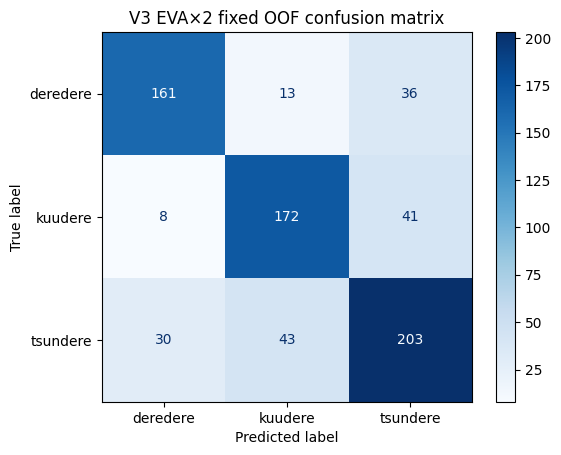

,fold,n,macro_f1
0,0,142,0.792699
1,1,142,0.818990
2,2,142,0.693034
3,3,141,0.823338
4,4,140,0.673445


Total errors: 171


,character_id,character_name,label,fold,visual_cues,pred,correct,tfidf_pred,tfidf_conf,convnext_pred,...,siglip2_pred,siglip2_conf,nli_large_pred,nli_large_conf,modernbert_pred,modernbert_conf,nli_base_pred,nli_base_conf,deberta_base_pred,deberta_base_conf
1,5d9d37d82f187c39,"Suelecia ""Sue"" Zagan Analeit",kuudere,1,"looking at viewer, closed mouth, smile",tsundere,False,tsundere,0.640315,kuudere,...,kuudere,0.642514,tsundere,0.811440,tsundere,0.896347,tsundere,0.954281,tsundere,0.849156
2,ae50b1dc411ef8a1,Fate Testarossa,kuudere,2,"looking at viewer, smile, open mouth",tsundere,False,tsundere,0.832076,kuudere,...,deredere,0.432752,tsundere,0.579342,tsundere,0.920438,kuudere,0.622203,kuudere,0.603742
9,0a5801737ec39c61,Akuru Akutsu,kuudere,4,"sweatdrop, looking at viewer, open mouth",tsundere,False,tsundere,0.547914,tsundere,...,kuudere,0.606627,tsundere,0.938227,tsundere,0.832595,tsundere,0.883301,tsundere,0.870526
10,3ceb8266c349d0b9,Misaki Tokura,tsundere,0,"smile, closed mouth, looking at viewer",kuudere,False,kuudere,0.610366,kuudere,...,kuudere,0.561501,kuudere,0.887595,deredere,0.567888,kuudere,0.822123,kuudere,0.715679
15,a98e5947746a13eb,Yume Nijino,tsundere,2,"smile, open mouth, looking at viewer, blush, h...",deredere,False,deredere,0.681521,tsundere,...,deredere,0.647090,deredere,0.885581,deredere,0.835238,deredere,0.983582,deredere,0.861709
16,a29bd2d70c399053,Jinguuji Tsukasa,kuudere,0,looking at viewer,tsundere,False,tsundere,0.515992,tsundere,...,kuudere,0.626359,tsundere,0.606721,kuudere,0.639486,tsundere,0.608870,kuudere,0.626778
20,10cb8ed7f066b3e1,Chlammy Zell,tsundere,0,,kuudere,False,tsundere,0.480529,tsundere,...,kuudere,0.551487,tsundere,0.586831,kuudere,0.683294,tsundere,0.661817,tsundere,0.675918
22,91cb3855a13d1536,Rain / Rhaenys Crowder,deredere,1,"smile, looking at viewer, closed mouth, blush",tsundere,False,tsundere,0.705325,tsundere,...,tsundere,0.603738,tsundere,0.758230,tsundere,0.540255,kuudere,0.501335,tsundere,0.702685
30,2782e022f4c75261,Kazuho Miyauchi,kuudere,4,"closed eyes, closed mouth, smile, light smile",tsundere,False,tsundere,0.471094,kuudere,...,deredere,0.380159,tsundere,0.520673,tsundere,0.811928,tsundere,0.472227,tsundere,0.690972
33,5e78ce578ffe9e79,Kuromi,tsundere,2,"smile, looking at viewer, open mouth",deredere,False,deredere,0.554594,deredere,...,deredere,0.839558,deredere,0.679235,tsundere,0.637864,deredere,0.851644,tsundere,0.512779


In [40]:
analysis_pred = eva_x2_oof_pred if eva_x2_oof_pred is not None else main_meta['oof_pred']
analysis_name = 'V3 EVA×2 fixed OOF' if eva_x2_oof_pred is not None else 'V3 honest meta OOF'

print(analysis_name)
print(classification_report(y_id, analysis_pred, target_names=LABELS, digits=4))
cm = confusion_matrix(y_id, analysis_pred, labels=np.arange(3))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(cmap='Blues')
plt.title(f'{analysis_name} confusion matrix')
plt.show()

fold_rows=[]
for f in range(N_FOLDS):
    m = train.fold.to_numpy() == f
    fold_rows.append({'fold': f, 'n': int(m.sum()), 'macro_f1': macro(y_id[m], analysis_pred[m])})
fold_perf = pd.DataFrame(fold_rows)
display(fold_perf)

err = train[['character_id','character_name','label','fold','personality','visual_cues']].copy()
err['pred'] = np.array(LABELS)[analysis_pred]
err['correct'] = analysis_pred == y_id
for n,p in branch_oof.items():
    err[f'{n}_pred'] = np.array(LABELS)[p.argmax(1)]
    err[f'{n}_conf'] = p.max(1)
err.to_csv(ARTIFACT_DIR/'v3_final_error_analysis.csv', index=False)
print('Total errors:', int((~err.correct).sum()))
display(err.loc[~err.correct, [c for c in err.columns if c != 'personality']].head(30))


> ### Insights
> Fold 2 dan fold 4 berulang kali menjadi fold tersulit pada berbagai keluarga model. Karena pola tersebut konsisten, keduanya lebih masuk akal diperlakukan sebagai kumpulan contoh ambigu/sulit daripada sekadar pembagian fold yang buruk. Eksperimen V8/V9 juga menunjukkan bahwa “mendeteksi row sulit” tidak otomatis berarti kita mengetahui label alternatif yang benar.


---

## Explainability Analysis

Tiga permukaan penjelasan digunakan tanpa mengklaim hubungan kausal:

1. koefisien word/character n-gram pada TF-IDF;
2. trait prototype dan probability entailment pada NLI;
3. tag visual EVA yang mempunyai koefisien tinggi pada head supervised.

Selain itu, tabel probability antarbranch pada sebuah karakter dapat menunjukkan apakah keputusan final muncul dari konsensus atau dari satu expert yang mengoreksi expert lain.


In [41]:
print("Final stable NLI hypotheses:")
for c in LABELS: print(c,"=>",make_hypothesis(c,full_traits[c],0))

if eva_tags_tr is not None:
    sel=SelectKBest(f_classif,k=min(512,eva_tags_tr.shape[1])); X=sel.fit_transform(eva_tags_tr,y_label); sc=StandardScaler(); X=sc.fit_transform(X)
    m=LogisticRegression(C=.2,max_iter=4000,class_weight="balanced",random_state=SEED); m.fit(X,y_label); names=np.asarray(eva_tag_names,dtype=object)[sel.get_support(indices=True)]
    rows=[]
    for ci,cls in enumerate(m.classes_):
        for rank,j in enumerate(np.argsort(m.coef_[ci])[-12:][::-1],1): rows.append({"class":cls,"rank":rank,"tag":str(names[j]),"coef":float(m.coef_[ci,j])})
    display(pd.DataFrame(rows).pivot(index="rank",columns="class",values="tag"))


Final stable NLI hypotheses:
deredere => This character fits the deredere archetype; the training data associates it with traits such as cheerful, optimistic, energetic, happy, carefree, loving, positive, loves, childish.
kuudere => This character fits the kuudere archetype; the training data associates it with traits such as cold, quiet, stoic, emotions, emotion, emotionless, reserved, rarely, calm.
tsundere => This character fits the tsundere archetype; the training data associates it with traits such as embarrassed, pride, actually, seriously, comes, temper, seeing, usagi, stubborn.


class,deredere,kuudere,tsundere
rank,,,
1,smile,expressionless,>:(
2,emoji,dress,blue_ribbon
3,large_breasts,white_jacket,light_censor
4,red_hairband,multi-strapped_bikini_bottom,sanpaku
5,grey_suit,unbuttoned,instagram_username
6,one_side_up,gradient_background,69
7,huge_ahoge,gym_uniform,copyright_name
8,light_frown,frown,small_penis
9,short_hair,holding_fishing_rod,credits


---

## Visualisasi Disagreement Expert


In [42]:
if all(k in branch_oof for k in ['nli_large','modernbert','eva02']):
    probe = pd.DataFrame({
        'character_name': train.character_name,
        'label': train.label,
        'nli': np.array(LABELS)[branch_oof['nli_large'].argmax(1)],
        'modern': np.array(LABELS)[branch_oof['modernbert'].argmax(1)],
        'eva': np.array(LABELS)[branch_oof['eva02'].argmax(1)],
        'final': np.array(LABELS)[analysis_pred],
        'nli_conf': branch_oof['nli_large'].max(1),
        'modern_conf': branch_oof['modernbert'].max(1),
        'eva_conf': branch_oof['eva02'].max(1),
    })
    disagree = probe[(probe[['nli','modern','eva']].nunique(axis=1) > 1)]
    display(disagree.sort_values('nli_conf', ascending=False).head(20))


,character_name,label,nli,modern,eva,final,nli_conf,modern_conf,eva_conf
73,Kongou Daijihishou Jizou Bosatsu / Adamant,kuudere,kuudere,kuudere,tsundere,kuudere,0.970590,0.906588,0.894370
654,Mikan Sakura,deredere,deredere,deredere,tsundere,deredere,0.967214,0.943770,0.983576
5,Ai Miyashita,deredere,deredere,deredere,tsundere,deredere,0.963717,0.971258,1.000000
78,Isuzu Sento,kuudere,kuudere,kuudere,tsundere,kuudere,0.963143,0.688901,0.804315
60,Eris,deredere,deredere,deredere,tsundere,deredere,0.959682,0.648984,0.780870
454,Karuta Roromiya,kuudere,kuudere,kuudere,tsundere,kuudere,0.958016,0.744073,1.000000
504,Mel Shidou,deredere,deredere,deredere,tsundere,deredere,0.957613,0.920857,0.976163
576,Nicol Ascart,kuudere,kuudere,kuudere,tsundere,kuudere,0.957554,0.960227,0.956748
385,Sora Sohma,deredere,deredere,deredere,tsundere,deredere,0.953302,0.887747,0.980307
684,Tsuyuno Yatsumura,kuudere,kuudere,kuudere,tsundere,kuudere,0.952586,0.896381,0.997898


> ### Insights
> EVA tidak perlu menjadi classifier terbaik untuk berkontribusi. Yang penting adalah apakah kesalahannya berbeda dari text expert. Public progression `NLI → text core → multimodal main → EVA×2` merupakan evidence paling kuat bahwa complementarity lebih penting daripada standalone score.


---
## Real-World Testing: Aldoy dan Diri Sendiri

Task #3 mewajibkan dua *real-world test*: **Aldoy** menggunakan foto dan *personality* yang disediakan pada soal, serta **diri sendiri** menggunakan foto pilihan dan deskripsi singkat. Bagian ini sengaja menjadi bagian dari `Run All`, bukan sekadar *hook* opsional.

Notebook mencari dua file dengan **nama persis** `aldoy.png` dan `riantama.png` secara rekursif dari Kaggle Input. Dengan begitu, notebook tidak bergantung pada username, dataset slug, atau mount path tertentu. Jika terdapat lebih dari satu file dengan nama sama, kandidat dari input yang mengandung `task3-labai` diprioritaskan secara deterministik. Pada full run, notebook akan berhenti dengan pesan yang jelas jika salah satu gambar tidak ditemukan.

Untuk diri sendiri, *human prior* yang dipakai adalah **deredere**. Penilaian ini **berasal dari deskripsi tertulis, bukan dari penampilan pada foto**: deskripsi menekankan sifat sosial, antusias bertukar cerita dan pengetahuan, keinginan membangun kedekatan, serta menawarkan dukungan akademik maupun personal. Trait tersebut paling dekat dengan pola *deredere* pada dataset yang cenderung hangat, terbuka, suportif, dan ekspresif. Prediksi model tetap dihitung secara independen; apabila berbeda, ketidaksesuaian tersebut dianalisis sebagai bagian dari pengujian.


Aldoy image: /kaggle/input/datasets/riantamaputra/task3-labai/aldoy.png
Self image : /kaggle/input/datasets/riantamaputra/task3-labai/riantama.png
Self human prior: deredere
Rationale: Deskripsi menekankan sifat sosial, terbuka, suportif, suka membangun kedekatan, dan menawarkan bantuan akademik maupun personal; pola ini paling dekat dengan deredere.


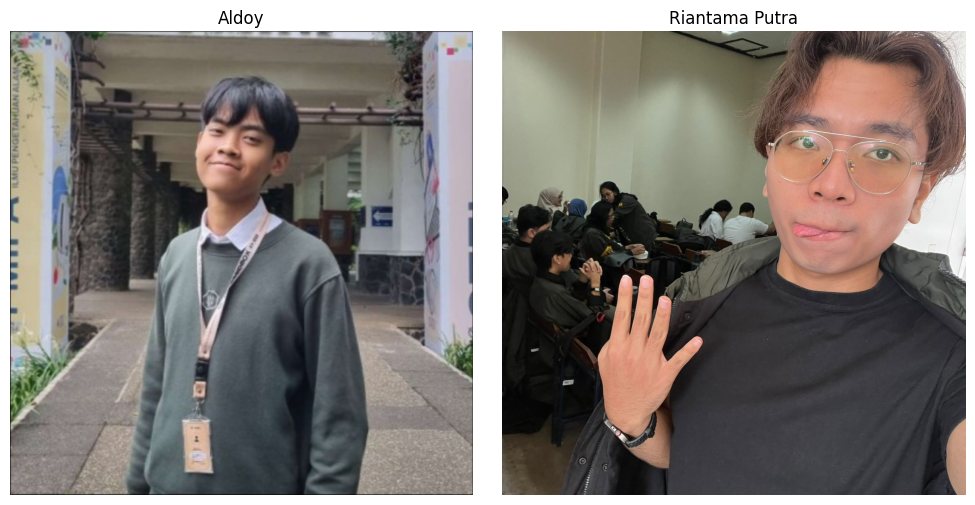


Aldoy personality:
 Well salken guys, Aldoy STI’23. Sekarang sedang bertanggungjawab sebagai Wakakom Pengawasan DPP HMIF dan Presiden Genshiken, lagi magang dan kadang ikut lomba CTF bareng King Lakmen dan Fajar, kemarin sempet jadi ketua GIM Apprenticeship dan GIMJAM juga.

Sedang minat di gamedev & Cysec so mari kita belajar bareng 🤩😋 Oh yea sekarang aku lagi ikut seleksi lab Sister and I have quite a high chance (ga ada saingan STI Nangor jirrr 😹😹) jadi bisa lah nanti kalian ada "koneksi" di bagian ini.

Bagi yang mau ngomongin anime dsb juga gaskan. ̶T̶i̶d̶a̶k̶ ̶m̶e̶n̶e̶r̶i̶m̶a̶ ̶d̶e̶s̶u̶h̶ ̶y̶a̶n̶g̶ ̶j̶o̶m̶o̶k̶ ̶l̶o̶h̶y̶a̶. I'm pretty sure I can help you in some aspects like academics, organizations, career, or just as a friend to chat with. Bagi yang mau connect ke "various things" juga bisa kubantu, this is one of the benefits of me being your kasuh :)

Bagi yang penasaran lebih lanjut boleh chat aja atau cek dulu. I'm also a part of something very big 👀 See ya!

Self personali

In [43]:
ALDOY_PERSONALITY = 'Well salken guys, Aldoy STI’23. Sekarang sedang bertanggungjawab sebagai Wakakom Pengawasan DPP HMIF dan Presiden Genshiken, lagi magang dan kadang ikut lomba CTF bareng King Lakmen dan Fajar, kemarin sempet jadi ketua GIM Apprenticeship dan GIMJAM juga.\n\nSedang minat di gamedev & Cysec so mari kita belajar bareng 🤩😋 Oh yea sekarang aku lagi ikut seleksi lab Sister and I have quite a high chance (ga ada saingan STI Nangor jirrr 😹😹) jadi bisa lah nanti kalian ada "koneksi" di bagian ini.\n\nBagi yang mau ngomongin anime dsb juga gaskan. ̶T̶i̶d̶a̶k̶ ̶m̶e̶n̶e̶r̶i̶m̶a̶ ̶d̶e̶s̶u̶h̶ ̶y̶a̶n̶g̶ ̶j̶o̶m̶o̶k̶ ̶l̶o̶h̶y̶a̶. I\'m pretty sure I can help you in some aspects like academics, organizations, career, or just as a friend to chat with. Bagi yang mau connect ke "various things" juga bisa kubantu, this is one of the benefits of me being your kasuh :)\n\nBagi yang penasaran lebih lanjut boleh chat aja atau cek dulu. I\'m also a part of something very big 👀 See ya!'

SELF_NAME = "Riantama Putra"
SELF_PERSONALITY = 'hai guys! kenalin gua rian, mungkin kalian kenal sebelumnya sebagai rian mentor klan 5, rian datsci, rian gymbro dll dll... tentunya gua punya minat utama di data science & AI 🤔tapi juga passion untuk explore hal2 lain seperti web development dan business. gua sangat suka dengerin reality club, kalo ada sesama kawan gua hmu mari kita konser bareng 🤘🤘 hobi gua seputar ngegym, memasak, dengerin musik, dan ngopi, intinya banyak hal yang seputar itu deh! paling seru kalo bisa convo deep talk atau tukar ilmu pandangan panjang, asik banget (kalo guenya ikut asikin dong :p) hmmm jujur gua lagi nyari 2 adek asuh aja (mungkin bisa nambah) karena pengen bener2 deket nanti ya (udah ada 1 calon actually). kalo misalnya kalian nanti jadi desuh gua, ofcourse selain gua bantu secara akademik (drive pribadi & writing soal data science), gua akan menjadi teman curhat dan bercerita, tukar pikiran, dan tentunya kalo kita share interest yang sama, bisa terus asikin dan ketemuan terus!! 😌😌'
SELF_EXPECTED_ARCHETYPE = "deredere"
SELF_EXPECTED_RATIONALE = (
    "Deskripsi menekankan sifat sosial, terbuka, suportif, suka membangun kedekatan, "
    "dan menawarkan bantuan akademik maupun personal; pola ini paling dekat dengan deredere."
)

# Real-world images are discovered automatically so the notebook is portable across
# Kaggle account/dataset slugs. Exact filenames keep the lookup deterministic.
REAL_WORLD_SEARCH_ROOTS = [
    p for p in [Path("/kaggle/input"), Path("/mnt/data"), Path.cwd()]
    if p.exists()
]
REAL_WORLD_PREFERRED_HINTS = ("task3-labai",)


def resolve_real_world_image(filename: str) -> Path:
    hits = []
    for root_idx, root in enumerate(REAL_WORLD_SEARCH_ROOTS):
        for p in root.rglob(filename):
            if p.is_file():
                path_text = str(p).lower()
                preferred_penalty = 0 if all(h in path_text for h in REAL_WORLD_PREFERRED_HINTS) else 1
                hits.append((preferred_penalty, root_idx, len(p.parts), str(p), p))

    if not hits:
        searched = ", ".join(str(x) for x in REAL_WORLD_SEARCH_ROOTS)
        raise FileNotFoundError(
            f"{filename} tidak ditemukan. Upload file dengan nama persis '{filename}' "
            f"ke salah satu Kaggle Input. Search roots: {searched}"
        )

    hits.sort(key=lambda x: x[:-1])
    best = hits[0][-1]
    if len(hits) > 1:
        print(f"{filename}: {len(hits)} exact-name matches found; selected {best}")
    return best


if FAST_DEV_RUN:
    # Smoke mode may run outside Kaggle without the two real-world images.
    def _resolve_optional(filename):
        try:
            return resolve_real_world_image(filename)
        except FileNotFoundError:
            return None
    ALDOY_IMAGE_PATH = _resolve_optional("aldoy.png")
    SELF_IMAGE_PATH = _resolve_optional("riantama.png")
else:
    ALDOY_IMAGE_PATH = resolve_real_world_image("aldoy.png")
    SELF_IMAGE_PATH = resolve_real_world_image("riantama.png")

print("Aldoy image:", ALDOY_IMAGE_PATH)
print("Self image :", SELF_IMAGE_PATH)
print("Self human prior:", SELF_EXPECTED_ARCHETYPE)
print("Rationale:", SELF_EXPECTED_RATIONALE)

if ALDOY_IMAGE_PATH is not None and SELF_IMAGE_PATH is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, path, title in [
        (axes[0], ALDOY_IMAGE_PATH, "Aldoy"),
        (axes[1], SELF_IMAGE_PATH, "Riantama Putra"),
    ]:
        with Image.open(path) as im:
            ax.imshow(pil_ensure_rgb(im))
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("\nAldoy personality:\n", ALDOY_PERSONALITY)
print("\nSelf personality:\n", SELF_PERSONALITY)


### Fungsi Inferensi Deploy

Fungsi ini memuat model full-data yang baru disimpan. NLI menggunakan trait prototype final, ModernBERT merata-ratakan dua view teks, EVA menghasilkan tag sekaligus embedding dan visual cues, SigLIP2 menghasilkan image embedding, lalu probabilitas kelima branch digabungkan menggunakan bobot EVA×2.


In [44]:
def _align_proba_from_classifier(clf, proba):
    out = np.zeros((len(proba), len(LABELS)), dtype=float)
    for j, cls in enumerate(clf.classes_): out[:, LABEL2ID[str(cls)]] = proba[:, j]
    return out


def _extract_one_eva(image_path):
    import torch, timm
    from timm.data import create_transform, resolve_data_config
    from huggingface_hub import hf_hub_download
    model = timm.create_model(f'hf_hub:{EVA_MODEL_NAME}', pretrained=True).to('cuda:0' if torch.cuda.is_available() else 'cpu').eval()
    device = next(model.parameters()).device
    transform = create_transform(**resolve_data_config(model.pretrained_cfg, model=model))
    tags_csv = hf_hub_download(repo_id=EVA_MODEL_NAME, filename='selected_tags.csv')
    labels_df = pd.read_csv(tags_csv, usecols=['name','category'])
    gen_idx = np.where(labels_df.category.to_numpy() == 0)[0]
    names = labels_df.loc[gen_idx, 'name'].tolist()
    with Image.open(image_path) as im:
        x = transform(pil_pad_square(pil_ensure_rgb(im))).unsqueeze(0)[:, [2,1,0], :, :].to(device)
    with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device.type=='cuda')):
        feat = model.forward_features(x); emb = model.forward_head(feat, pre_logits=True); logits = model.forward_head(feat, pre_logits=False)
    tags = torch.sigmoid(logits)[:, gen_idx].float().cpu().numpy(); emb = emb.float().cpu().numpy()
    del model; clean_cuda()
    return tags, emb, names


def _extract_one_siglip(image_path):
    import torch
    from transformers import AutoProcessor, AutoModel
    processor = AutoProcessor.from_pretrained(SIGLIP2_MODEL_NAME)
    model = AutoModel.from_pretrained(SIGLIP2_MODEL_NAME).to('cuda:0' if torch.cuda.is_available() else 'cpu').eval()
    device = next(model.parameters()).device
    with Image.open(image_path) as im: image = pil_pad_square(pil_ensure_rgb(im)).copy()
    batch = processor(images=[image], return_tensors='pt'); batch = {k:v.to(device) for k,v in batch.items()}
    with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device.type=='cuda')):
        e = model.get_image_features(**batch)
    e = torch.nn.functional.normalize(e.float(), dim=1).cpu().numpy()
    del model, processor; clean_cuda()
    return e


def infer_character(name, personality, image_path):
    if not TRAIN_FINAL_DEPLOY_MODELS:
        raise RuntimeError('Set TRAIN_FINAL_DEPLOY_MODELS=1 dan jalankan training full-data terlebih dahulu.')
    if image_path is None or not Path(image_path).exists():
        raise FileNotFoundError('Foto real-world test belum ditemukan.')

    # EVA + visual cues
    eva_tags, eva_emb, eva_names = _extract_one_eva(image_path)
    cue = visual_cue_strings(eva_tags, eva_names)[0]
    eva_head = joblib.load(MODEL_DIR/'eva_full_head.joblib')
    a = eva_head['selector'].transform(eva_tags); X = np.hstack([a, eva_emb]); X = eva_head['scaler'].transform(X)
    eva_p = _align_proba_from_classifier(eva_head['classifier'], eva_head['classifier'].predict_proba(X))[0]

    # SigLIP2
    sig = _extract_one_siglip(image_path)
    sig_head = joblib.load(MODEL_DIR/'siglip2_full_head.joblib')
    Xs = sig_head['scaler'].transform(sig); sig_p = _align_proba_from_classifier(sig_head['classifier'], sig_head['classifier'].predict_proba(Xs))
    sig_T = float(sig_head.get('temperature', 1.0)); sig_p = softmax_np(np.log(np.clip(sig_p,1e-10,1))/sig_T)[0]

    # TF-IDF
    tf = joblib.load(MODEL_DIR/'tfidf_full.joblib')
    Xt = tf['vectorizer'].transform([personality]); tf_logits = aligned_scores(tf['classifier'], Xt)
    tf_p = softmax_np(tf_logits / float(tf['temperature']))[0]

    # NLI full-data
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    nli_dir = Path(FINAL_NLI_DIRS[0])
    tok = AutoTokenizer.from_pretrained(nli_dir); model = AutoModelForSequenceClassification.from_pretrained(nli_dir).to('cuda:0' if torch.cuda.is_available() else 'cpu').eval()
    cfg = model.config; ent = int(cfg.label2id.get('entailment',0)); notent = int(cfg.label2id.get('not_entailment',1)); device = next(model.parameters()).device
    temp_df = pd.DataFrame({'character_name':[name], 'personality':[personality], 'visual_cues':[cue]})
    nli_scores=[]
    for tid in range(len(HYP_TEMPLATES)):
        row=[]
        for cls in LABELS:
            premise = make_premise(temp_df, 0, with_visual=True); hyp = make_hypothesis(cls, full_traits[cls], tid)
            enc = tok(premise, hyp, truncation='only_first', max_length=NLI_MAXLEN, return_tensors='pt'); enc={k:v.to(device) for k,v in enc.items()}
            with torch.inference_mode(): lg=model(**enc).logits[0]
            row.append(float((lg[ent]-lg[notent]).detach().cpu()))
        nli_scores.append(row)
    nli_p = softmax_np(np.asarray(nli_scores).mean(0, keepdims=True) / float(NLI_LARGE_TEMP))[0]
    del model, tok; clean_cuda()

    # ModernBERT full-data
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    mtok=AutoTokenizer.from_pretrained(FINAL_MODERN_DIR); mmodel=AutoModelForSequenceClassification.from_pretrained(FINAL_MODERN_DIR).to('cuda:0' if torch.cuda.is_available() else 'cpu').eval(); device=next(mmodel.parameters()).device
    mps=[]
    for text in [personality, f'Character: {name}. Personality: {personality}']:
        enc=mtok(text, truncation=True, max_length=MODERN_MAXLEN, return_tensors='pt'); enc={k:v.to(device) for k,v in enc.items()}
        with torch.inference_mode(): lg=mmodel(**enc).logits.float().cpu().numpy()
        mps.append(softmax_np(lg))
    modern_p=np.mean(mps, axis=0); modern_p=softmax_np(np.log(np.clip(modern_p,1e-10,1))/float(MODERN_TEMP))[0]
    del mmodel, mtok; clean_cuda()

    probs={'nli_large':nli_p, 'modernbert':modern_p, 'tfidf':tf_p, 'eva02':eva_p, 'siglip2':sig_p}
    p=sum(float(eva_x2_weights[n])*probs[n] for n in CORE_NAMES)
    score=np.log(np.clip(p,1e-12,1))+np.asarray(main_meta['bias'])
    pred=LABELS[int(score.argmax())]
    result=pd.DataFrame({n:probs[n] for n in CORE_NAMES}, index=LABELS).T
    return {'name':name, 'prediction':pred, 'probability':dict(zip(LABELS,p.tolist())), 'visual_cues':cue, 'branch_probabilities':result}


In [45]:
real_world_results = {}

def summarize_real_world_result(key, result, expected=None):
    probs = result["probability"]
    branch_df = result["branch_probabilities"].copy()
    branch_pred = branch_df.idxmax(axis=1).to_dict()
    sorted_probs = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
    margin = float(sorted_probs[0][1] - sorted_probs[1][1])

    print(f"\n{'='*72}")
    print(f"{result['name']} -> FINAL PREDICTION: {result['prediction']}")
    print("Final probability:", {k: round(v, 4) for k, v in probs.items()})
    print("Prediction margin:", round(margin, 4))
    print("Visual cues:", result["visual_cues"])
    print("Branch predictions:", branch_pred)
    display(branch_df.round(4))

    if expected is not None:
        match = result["prediction"] == expected
        print("Human prior       :", expected)
        print("Model vs human    :", "SESUAI" if match else "TIDAK SESUAI")
        if match:
            print(
                "Interpretasi: prediksi konsisten dengan self-assessment. "
                "Sifat sosial, suportif, terbuka untuk kedekatan, serta antusias berbagi "
                "aktivitas dan pengetahuan cocok dengan karakteristik deredere."
            )
        else:
            print(
                "Interpretasi: prediksi berbeda dari self-assessment deredere. "
                "Kemungkinan penyebab yang perlu diperhatikan adalah domain shift: train berisi "
                "deskripsi karakter fiksi yang mayoritas berbahasa Inggris dan gambar anime, sedangkan "
                "kasus ini memakai bahasa Indonesia informal/campuran dan foto manusia nyata. "
                "Periksa disagreement text-vs-image branch di tabel sebelum menyimpulkan model salah."
            )
    return {
        "key": key,
        "name": result["name"],
        "prediction": result["prediction"],
        "expected": expected,
        "match_expected": None if expected is None else result["prediction"] == expected,
        "margin": margin,
        **{f"p_{k}": float(v) for k, v in probs.items()},
        **{f"pred_{k}": v for k, v in branch_pred.items()},
    }

if not FAST_DEV_RUN and TRAIN_FINAL_DEPLOY_MODELS:
    cases = [
        ("aldoy", "Aldoy", ALDOY_PERSONALITY, ALDOY_IMAGE_PATH, None),
        ("self", SELF_NAME, SELF_PERSONALITY, SELF_IMAGE_PATH, SELF_EXPECTED_ARCHETYPE),
    ]
    summary_rows = []
    for key, nm, desc, path, expected in cases:
        if not Path(path).exists():
            raise FileNotFoundError(f"{key}: required image missing -> {path}")
        res = infer_character(nm, desc, path)
        real_world_results[key] = res
        summary_rows.append(summarize_real_world_result(key, res, expected=expected))

    real_world_summary = pd.DataFrame(summary_rows)
    display(real_world_summary)
    real_world_summary.to_csv(ARTIFACT_DIR / "real_world_test_summary.csv", index=False)

    serializable = {
        k: {
            "name": v["name"],
            "prediction": v["prediction"],
            "probability": {kk: float(vv) for kk, vv in v["probability"].items()},
            "visual_cues": v["visual_cues"],
            "branch_probabilities": v["branch_probabilities"].to_dict(),
        }
        for k, v in real_world_results.items()
    }
    (ARTIFACT_DIR / "real_world_test_results.json").write_text(
        json.dumps(serializable, ensure_ascii=False, indent=2)
    )
    print("Saved:", ARTIFACT_DIR / "real_world_test_summary.csv")
    print("Saved:", ARTIFACT_DIR / "real_world_test_results.json")
else:
    print("Real-world deployment inference dilewati pada FAST_DEV_RUN.")


config.json:   0%|          | 0.00/634 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...


Riantama Putra -> FINAL PREDICTION: deredere
Final probability: {'deredere': 0.729, 'kuudere': 0.0816, 'tsundere': 0.1894}
Prediction margin: 0.5396
Visual cues: tongue, looking at viewer, closed mouth, smile
Branch predictions: {'nli_large': 'deredere', 'modernbert': 'tsundere', 'tfidf': 'tsundere', 'eva02': 'deredere', 'siglip2': 'kuudere'}


,deredere,kuudere,tsundere
nli_large,0.9621,0.0102,0.0277
modernbert,0.1506,0.2608,0.5886
tfidf,0.2767,0.1520,0.5713
eva02,0.9994,0.0000,0.0005
siglip2,0.3069,0.4609,0.2322


Human prior       : deredere
Model vs human    : SESUAI
Interpretasi: prediksi konsisten dengan self-assessment. Sifat sosial, suportif, terbuka untuk kedekatan, serta antusias berbagi aktivitas dan pengetahuan cocok dengan karakteristik deredere.


,key,name,prediction,expected,match_expected,margin,p_deredere,p_kuudere,p_tsundere,pred_nli_large,pred_modernbert,pred_tfidf,pred_eva02,pred_siglip2
0,aldoy,Aldoy,deredere,None,None,0.325372,0.553155,0.227782,0.219063,deredere,tsundere,tsundere,kuudere,tsundere
1,self,Riantama Putra,deredere,deredere,True,0.539625,0.729019,0.081588,0.189394,deredere,tsundere,tsundere,deredere,kuudere


Saved: /kaggle/working/artifacts_v3/real_world_test_summary.csv
Saved: /kaggle/working/artifacts_v3/real_world_test_results.json


### Interpretasi Real-World Test

Interpretasi mengikuti dua prinsip. Pertama, prediksi tidak dinilai hanya dari label akhir, tetapi juga dari probabilitas dan *disagreement* antar-*expert*. Kedua, hasil pada manusia nyata harus diperlakukan sebagai pengujian *out-of-distribution*: model dilatih pada karakter anime/manga/light novel dan mayoritas deskripsi train menggunakan bahasa Inggris.

- **Aldoy** tidak memiliki *ground truth* resmi. Karena itu, pembahasan berfokus pada trait pada teks, *visual cues*, confidence, dan apakah *text expert* serta *image expert* memberikan sinyal yang konsisten.
- **Riantama Putra** menggunakan *human prior* `deredere`, yang ditentukan dari deskripsi diri, bukan dari foto. Jika model juga memprediksi `deredere`, hasil dianggap selaras dengan sifat sosial, suportif, dan keinginan membangun kedekatan yang tertulis pada deskripsi. Jika berbeda, tabel *branch probability* digunakan untuk melihat apakah penyebabnya lebih mungkin berasal dari bahasa informal/campuran, domain gambar manusia-vs-anime, atau trait yang ditafsirkan berbeda oleh model.

Dengan demikian, dua kasus ini bukan sekadar demo inferensi, tetapi *stress test* kecil terhadap generalisasi model di luar distribusi kompetisi.


---

## Ringkasan Final


In [46]:
print('=== FINAL DERE DETECTOR SUMMARY ===')
print('Train/Test:', len(train), len(test))
print('TF-IDF OOF:', round(tfidf_f1,5))
print('Zero-Transformer multimodal OOF:', round(nontrans_f1,5))
print('ConvNeXt OOF:', None if conv_f1 is None else round(conv_f1,5))
print('EVA02 OOF:', None if eva_f1 is None else round(eva_f1,5))
print('SigLIP2 OOF:', None if siglip_f1 is None else round(siglip_f1,5))
print('NLI-large OOF:', None if nli_large_f1 is None else round(nli_large_f1,5))
print('ModernBERT OOF:', None if modern_f1 is None else round(modern_f1,5))
print('V3 main honest meta-OOF:', round(main_meta['honest_f1'],5))
print('V3 main fixed OOF:', round(macro(y_id,fixed_pred),5))
print('V3 EVA×2 fixed OOF:', None if eva_x2_f1 is None else round(eva_x2_f1,5))
print('Final weights:', None if eva_x2_weights is None else {k:round(v,5) for k,v in eva_x2_weights.items()})
print('Public reference: V3 main 0.81391 -> V3 EVA×2 0.83504')
print('Final submission:', WORK_DIR/'submission_v3_eva_x2.csv')
print('Elapsed hours:', round(elapsed_h(),2), '| Free disk GB:', round(disk_free_gb(),2))

print("Real-world tests:", "completed" if bool(real_world_results) else "skipped (FAST_DEV_RUN)")


=== FINAL DERE DETECTOR SUMMARY ===
Train/Test: 707 302
TF-IDF OOF: 0.59595
Zero-Transformer multimodal OOF: 0.62253
ConvNeXt OOF: 0.50862
EVA02 OOF: 0.56179
SigLIP2 OOF: 0.48762
NLI-large OOF: 0.75186
ModernBERT OOF: 0.70843
V3 main honest meta-OOF: 0.73933
V3 main fixed OOF: 0.75641
V3 EVA×2 fixed OOF: 0.76122
Final weights: {'nli_large': 0.52906, 'modernbert': 0.2484, 'tfidf': 0.04587, 'eva02': 0.16708, 'siglip2': 0.00959}
Public reference: V3 main 0.81391 -> V3 EVA×2 0.83504
Final submission: /kaggle/working/submission_v3_eva_x2.csv
Elapsed hours: 4.41 | Free disk GB: 16.36
Real-world tests: completed


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Daftar Pustaka <a name="9"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


He, P., Liu, X., Gao, J., & Chen, W. (2021). *DeBERTa: Decoding-enhanced BERT with Disentangled Attention*. ICLR 2021. arXiv:2006.03654.

Laurer, M. dkk. `MoritzLaurer/deberta-v3-large-zeroshot-v2.0`. Hugging Face model card. Checkpoint NLI encoder yang digunakan sebagai primary semantic expert.

Warner, B. dkk. (2024). *Smarter, Better, Faster, Longer: A Modern Bidirectional Encoder for Fast, Memory Efficient, and Long Context Finetuning and Inference*. arXiv:2412.13663. Model yang digunakan: `answerdotai/ModernBERT-large`.

Tschannen, M. dkk. (2025). *SigLIP 2: Multilingual Vision-Language Encoders with Improved Semantic Understanding, Localization, and Dense Features*. arXiv.

SmilingWolf. `wd-convnext-tagger-v3` dan `wd-eva02-large-tagger-v3`. Hugging Face model cards untuk anime image tagging.

Pedregosa, F. dkk. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.

The Dere Types Wiki. Sumber kategori yang digunakan dalam konstruksi dataset kompetisi Dere Detector.


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Thanks! <a name=""></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">


**Terima kasih khusus kepada:**

Tim Asisten **Laboratorium Intelegensi Buatan 2023** yang telah menyiapkan Task #3 dan kompetisi Dere Detector sebagai ruang untuk menguji bukan hanya skor model, tetapi juga pemahaman terhadap validasi, multimodal learning, error analysis, explainability, dan tanggung jawab dalam membangun sistem AI.
